In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("sinus_survey_data1.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'sinus_survey_data1.csv'

In [ ]:
print(df.shape)

(1006, 11)


In [ ]:
df.head()

,Age,Gender,Regular Sinus Issues,Most Problematic Season,Triggered by External Factors,Known Allergy,Doctor Consulted (Past Year),Sinus Severity (1-5),Diagnosed with Sinus Condition,Headaches or Facial Pain,Medication Frequency
0,43,Female,No,Monsoon / Rainy,Yes,Yes,No,4,Yes,No,Occasionally
1,55,Female,Yes,Monsoon / Rainy,No,Yes,Yes,3,Yes,Yes,Occasionally
2,48,Male,Yes,Winter,Yes,Yes,No,2,No,Yes,Occasionally
3,65,Male,Yes,Winter,Yes,No,Yes,4,No,Yes,Occasionally
4,34,Female,No,Winter,Yes,No,Yes,1,No,Yes,Regularly


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Age                             1006 non-null   int64
 1   Gender                          1006 non-null   str  
 2   Regular Sinus Issues            1006 non-null   str  
 3   Most Problematic Season         1006 non-null   str  
 4   Triggered by External Factors   1006 non-null   str  
 5   Known Allergy                   1006 non-null   str  
 6   Doctor Consulted (Past Year)    1006 non-null   str  
 7   Sinus Severity (1-5)            1006 non-null   int64
 8   Diagnosed with Sinus Condition  1006 non-null   str  
 9   Headaches or Facial Pain        1006 non-null   str  
 10  Medication Frequency            1006 non-null   str  
dtypes: int64(2), str(9)
memory usage: 86.6 KB


In [ ]:
df.isnull().sum()

Age                               0
Gender                            0
Regular Sinus Issues              0
Most Problematic Season           0
Triggered by External Factors     0
Known Allergy                     0
Doctor Consulted (Past Year)      0
Sinus Severity (1-5)              0
Diagnosed with Sinus Condition    0
Headaches or Facial Pain          0
Medication Frequency              0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(6)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Regular Sinus Issues', 'Most Problematic Season',
       'Triggered by External Factors', 'Known Allergy',
       'Doctor Consulted (Past Year)', 'Sinus Severity (1-5)',
       'Diagnosed with Sinus Condition', 'Headaches or Facial Pain',
       'Medication Frequency'],
      dtype='str')

In [ ]:
df.describe()

,Age,Sinus Severity (1-5)
count,1006.000000,1006.000000
mean,41.528827,2.950298
std,14.035090,1.440534
min,18.000000,1.000000
25%,30.000000,2.000000
50%,41.000000,3.000000
75%,54.000000,4.000000
max,65.000000,5.000000


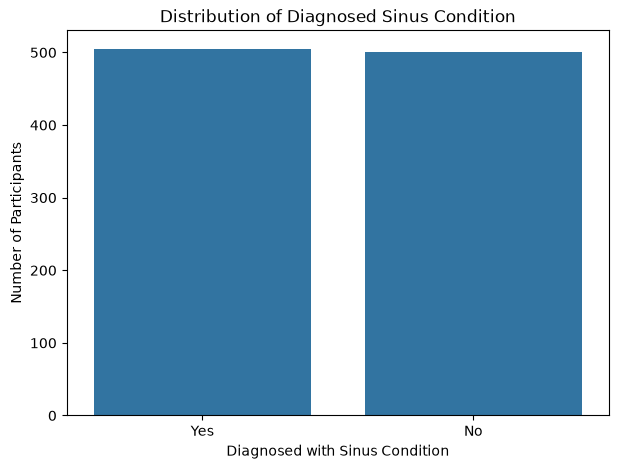

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Diagnosed with Sinus Condition'
)

plt.title('Distribution of Diagnosed Sinus Condition')
plt.xlabel('Diagnosed with Sinus Condition')
plt.ylabel('Number of Participants')
plt.show()

In [ ]:
print(df['Diagnosed with Sinus Condition'].value_counts())

Diagnosed with Sinus Condition
Yes    505
No     501
Name: count, dtype: int64


In [ ]:
print(df['Diagnosed with Sinus Condition'].value_counts(normalize=True) * 100)

Diagnosed with Sinus Condition
Yes    50.198807
No     49.801193
Name: proportion, dtype: float64


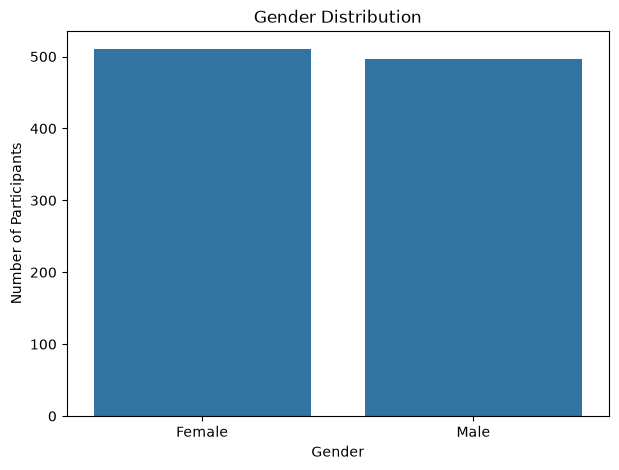

Gender
Female    510
Male      496
Name: count, dtype: int64
Gender
Female    50.695825
Male      49.304175
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Participants')
plt.show()

print(df['Gender'].value_counts())
print(df['Gender'].value_counts(normalize=True) * 100)

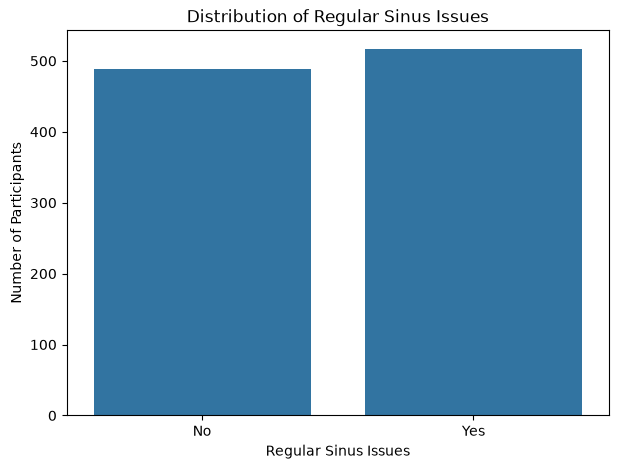

Regular Sinus Issues
Yes    517
No     489
Name: count, dtype: int64
Regular Sinus Issues
Yes    51.39165
No     48.60835
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Regular Sinus Issues'
)

plt.title('Distribution of Regular Sinus Issues')
plt.xlabel('Regular Sinus Issues')
plt.ylabel('Number of Participants')
plt.show()

print(df['Regular Sinus Issues'].value_counts())
print(df['Regular Sinus Issues'].value_counts(normalize=True) * 100)

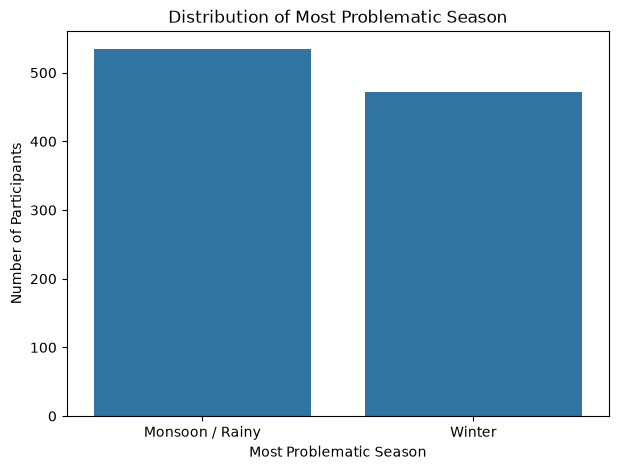

Most Problematic Season
Monsoon / Rainy    534
Winter             472
Name: count, dtype: int64
Most Problematic Season
Monsoon / Rainy    53.081511
Winter             46.918489
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Most Problematic Season'
)

plt.title('Distribution of Most Problematic Season')
plt.xlabel('Most Problematic Season')
plt.ylabel('Number of Participants')
plt.show()

print(df['Most Problematic Season'].value_counts())
print(df['Most Problematic Season'].value_counts(normalize=True) * 100)

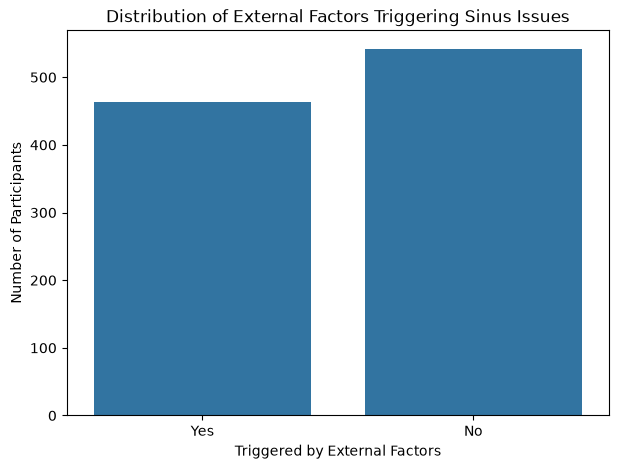

Triggered by External Factors
No     542
Yes    464
Name: count, dtype: int64
Triggered by External Factors
No     53.87674
Yes    46.12326
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Triggered by External Factors'
)

plt.title('Distribution of External Factors Triggering Sinus Issues')
plt.xlabel('Triggered by External Factors')
plt.ylabel('Number of Participants')
plt.show()

print(df['Triggered by External Factors'].value_counts())
print(df['Triggered by External Factors'].value_counts(normalize=True) * 100)

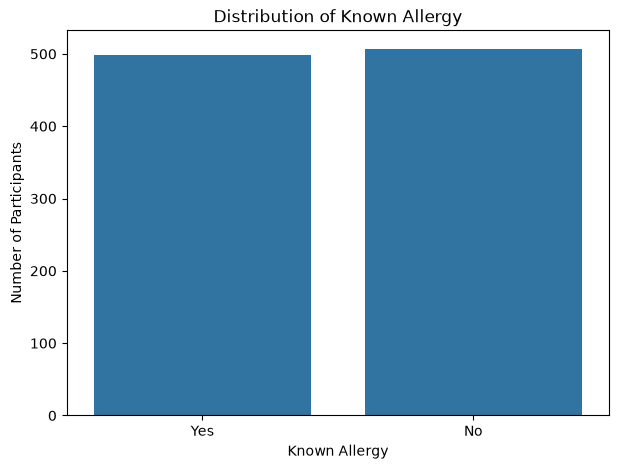

Known Allergy
No     507
Yes    499
Name: count, dtype: int64
Known Allergy
No     50.397614
Yes    49.602386
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Known Allergy'
)

plt.title('Distribution of Known Allergy')
plt.xlabel('Known Allergy')
plt.ylabel('Number of Participants')
plt.show()

print(df['Known Allergy'].value_counts())
print(df['Known Allergy'].value_counts(normalize=True) * 100)

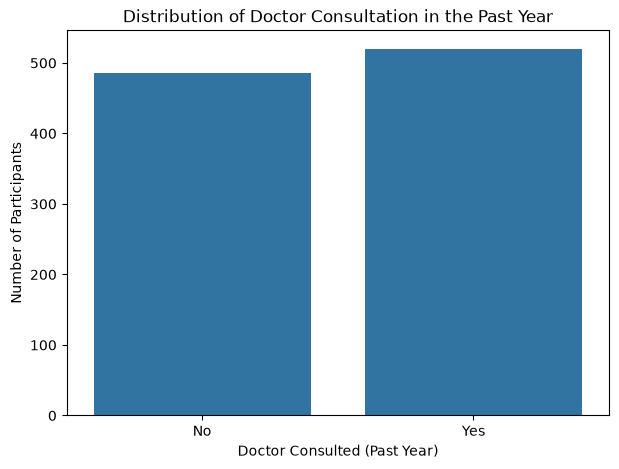

Doctor Consulted (Past Year)
Yes    520
No     486
Name: count, dtype: int64
Doctor Consulted (Past Year)
Yes    51.689861
No     48.310139
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Doctor Consulted (Past Year)'
)

plt.title('Distribution of Doctor Consultation in the Past Year')
plt.xlabel('Doctor Consulted (Past Year)')
plt.ylabel('Number of Participants')
plt.show()

print(df['Doctor Consulted (Past Year)'].value_counts())
print(df['Doctor Consulted (Past Year)'].value_counts(normalize=True) * 100)

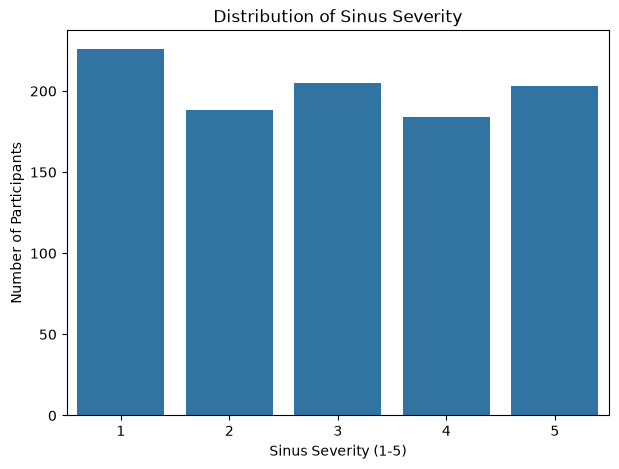

Sinus Severity (1-5)
1    226
2    188
3    205
4    184
5    203
Name: count, dtype: int64
Sinus Severity (1-5)
1    22.465209
2    18.687873
3    20.377734
4    18.290258
5    20.178926
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Sinus Severity (1-5)'
)

plt.title('Distribution of Sinus Severity')
plt.xlabel('Sinus Severity (1-5)')
plt.ylabel('Number of Participants')
plt.show()

print(df['Sinus Severity (1-5)'].value_counts().sort_index())
print(df['Sinus Severity (1-5)'].value_counts(normalize=True).sort_index() * 100)

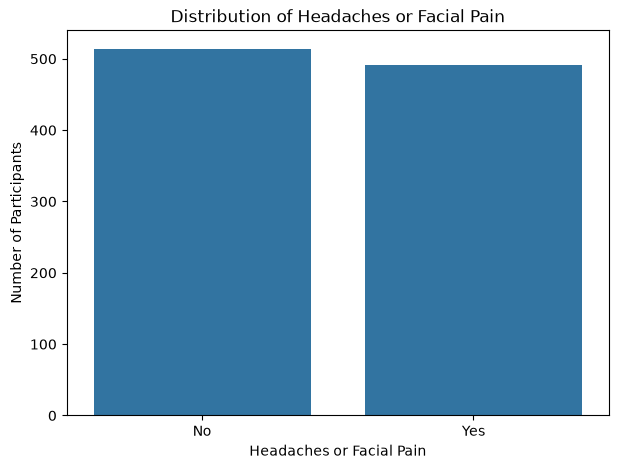

Headaches or Facial Pain
No     514
Yes    492
Name: count, dtype: int64
Headaches or Facial Pain
No     51.093439
Yes    48.906561
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Headaches or Facial Pain'
)

plt.title('Distribution of Headaches or Facial Pain')
plt.xlabel('Headaches or Facial Pain')
plt.ylabel('Number of Participants')
plt.show()

print(df['Headaches or Facial Pain'].value_counts())
print(df['Headaches or Facial Pain'].value_counts(normalize=True) * 100)

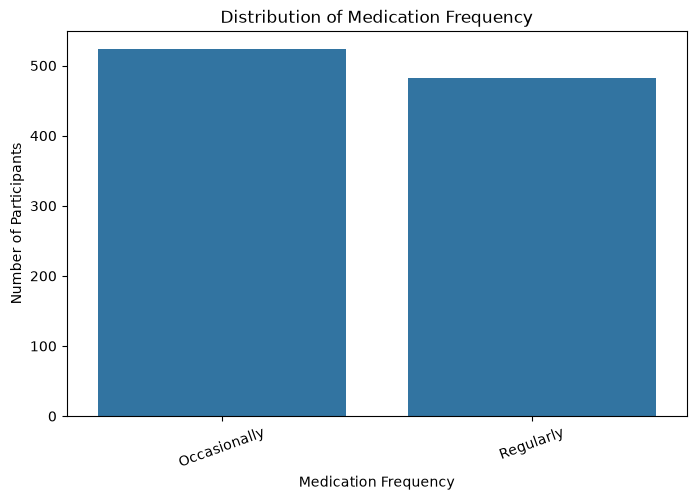

Medication Frequency
Occasionally    523
Regularly       483
Name: count, dtype: int64
Medication Frequency
Occasionally    51.988072
Regularly       48.011928
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Medication Frequency'
)

plt.title('Distribution of Medication Frequency')
plt.xlabel('Medication Frequency')
plt.ylabel('Number of Participants')
plt.xticks(rotation=20)
plt.show()

print(df['Medication Frequency'].value_counts())
print(df['Medication Frequency'].value_counts(normalize=True) * 100)

In [ ]:
# Cross-tabulation: Known Allergy vs Diagnosis

cross_tab = pd.crosstab(
    df['Known Allergy'],
    df['Diagnosed with Sinus Condition']
)

print(cross_tab)

Diagnosed with Sinus Condition   No  Yes
Known Allergy                           
No                              247  260
Yes                             254  245


In [ ]:
# Row-wise percentages

cross_tab_percent = pd.crosstab(
    df['Known Allergy'],
    df['Diagnosed with Sinus Condition'],
    normalize='index'
) * 100

print(cross_tab_percent.round(2))

Diagnosed with Sinus Condition     No    Yes
Known Allergy                               
No                              48.72  51.28
Yes                             50.90  49.10


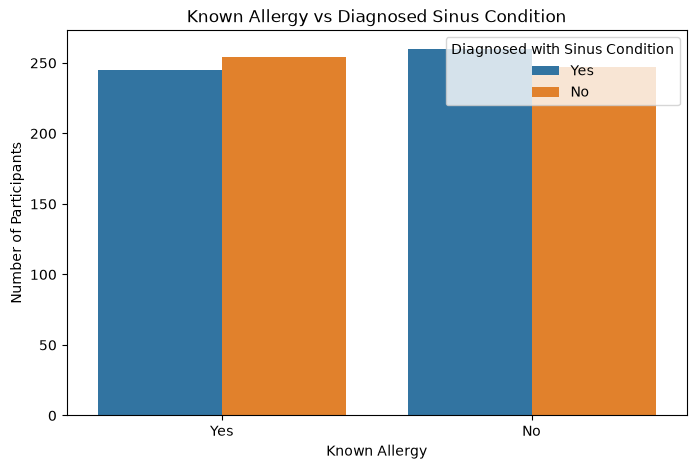

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Known Allergy',
    hue='Diagnosed with Sinus Condition'
)

plt.title('Known Allergy vs Diagnosed Sinus Condition')
plt.xlabel('Known Allergy')
plt.ylabel('Number of Participants')
plt.legend(title='Diagnosed with Sinus Condition')
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['Known Allergy'],
    df['Diagnosed with Sinus Condition']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 0.39638187578469264
p-value: 0.5289637474624262
Degrees of freedom: 1



Gender vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Gender                                  
Female                          248  262
Male                            253  243

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Gender                                      
Female                          48.63  51.37
Male                            51.01  48.99

CHI-SQUARE TEST:
Chi-square statistic: 0.4788
p-value: 0.4890
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


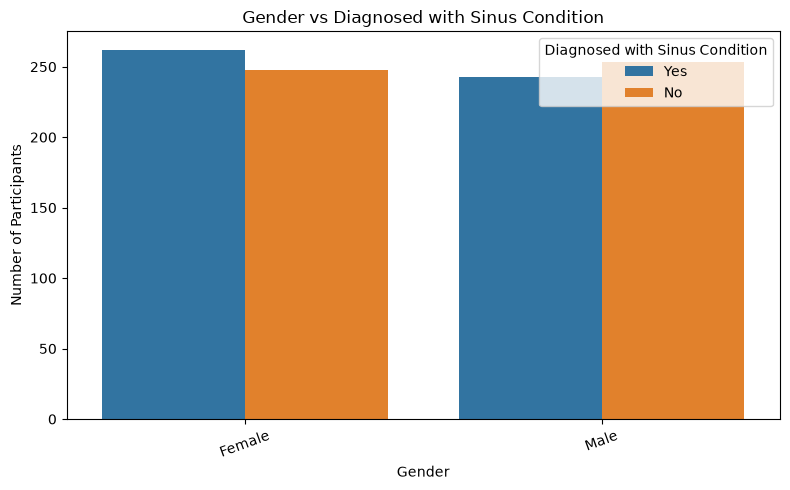


Regular Sinus Issues vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Regular Sinus Issues                    
No                              243  246
Yes                             258  259

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Regular Sinus Issues                        
No                              49.69  50.31
Yes                             49.90  50.10

CHI-SQUARE TEST:
Chi-square statistic: 0.0000
p-value: 0.9972
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


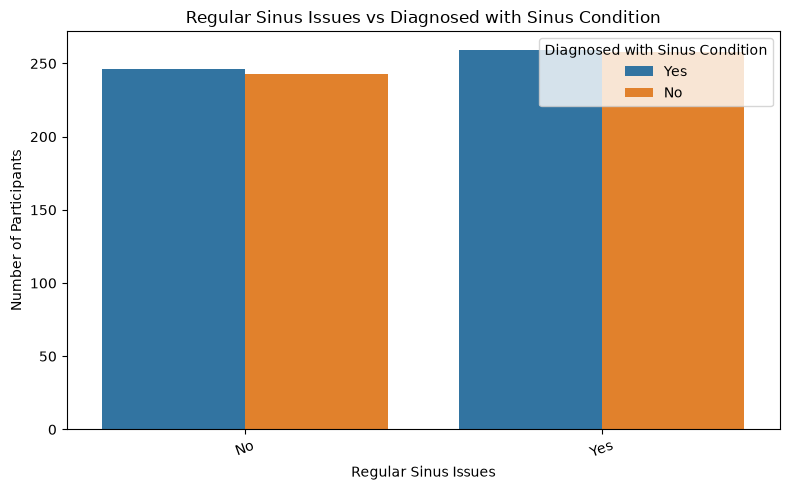


Most Problematic Season vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Most Problematic Season                 
Monsoon / Rainy                 273  261
Winter                          228  244

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Most Problematic Season                     
Monsoon / Rainy                 51.12  48.88
Winter                          48.31  51.69

CHI-SQUARE TEST:
Chi-square statistic: 0.6874
p-value: 0.4071
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


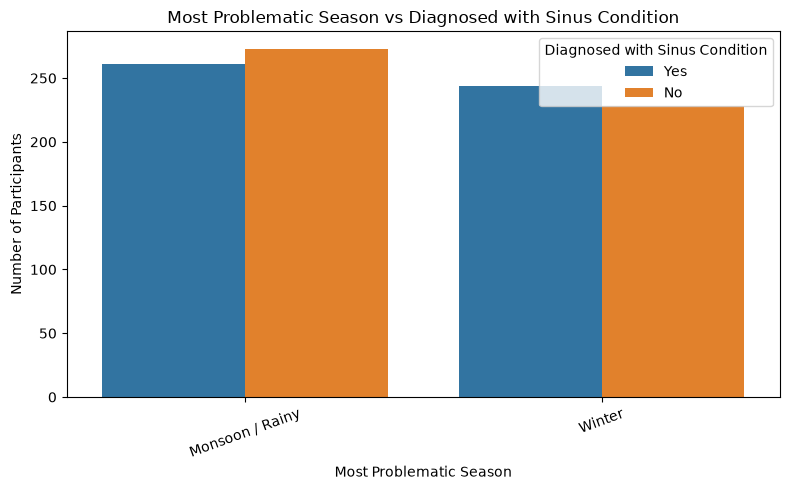


Triggered by External Factors vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Triggered by External Factors           
No                              285  257
Yes                             216  248

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Triggered by External Factors               
No                              52.58  47.42
Yes                             46.55  53.45

CHI-SQUARE TEST:
Chi-square statistic: 3.4003
p-value: 0.0652
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


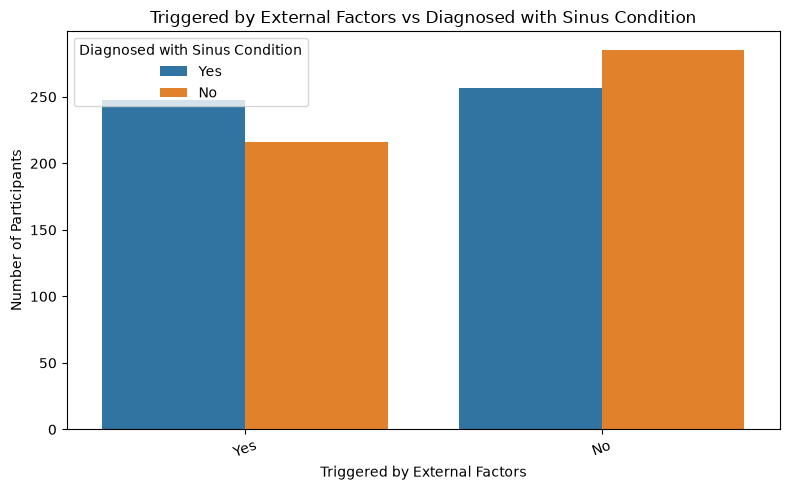


Known Allergy vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Known Allergy                           
No                              247  260
Yes                             254  245

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Known Allergy                               
No                              48.72  51.28
Yes                             50.90  49.10

CHI-SQUARE TEST:
Chi-square statistic: 0.3964
p-value: 0.5290
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


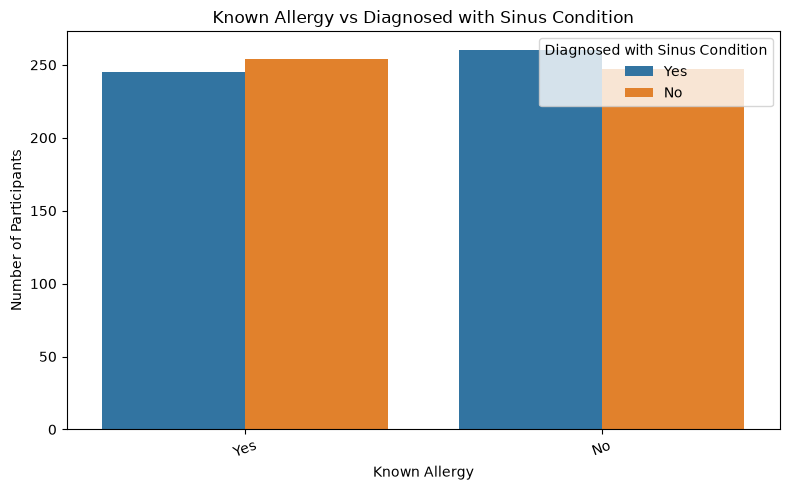


Doctor Consulted (Past Year) vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Doctor Consulted (Past Year)            
No                              245  241
Yes                             256  264

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Doctor Consulted (Past Year)                
No                              50.41  49.59
Yes                             49.23  50.77

CHI-SQUARE TEST:
Chi-square statistic: 0.0968
p-value: 0.7556
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


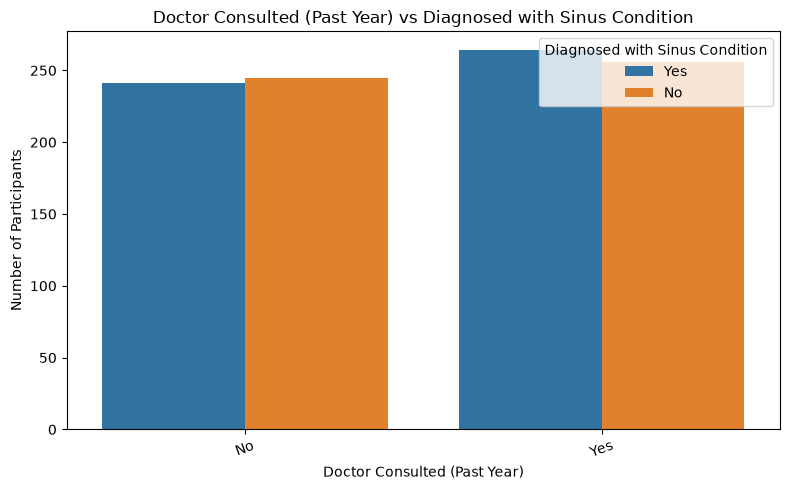


Headaches or Facial Pain vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Headaches or Facial Pain                
No                              249  265
Yes                             252  240

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Headaches or Facial Pain                    
No                              48.44  51.56
Yes                             51.22  48.78

CHI-SQUARE TEST:
Chi-square statistic: 0.6678
p-value: 0.4138
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


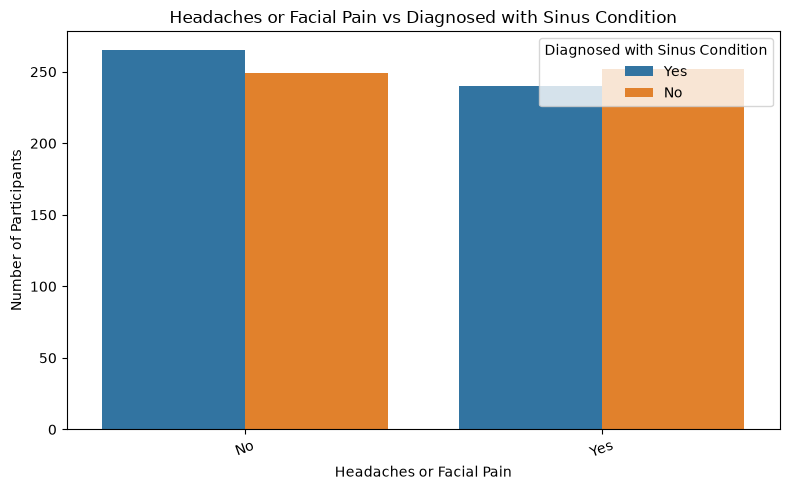


Medication Frequency vs Diagnosed with Sinus Condition

COUNT TABLE:
Diagnosed with Sinus Condition   No  Yes
Medication Frequency                    
Occasionally                    258  265
Regularly                       243  240

ROW-WISE PERCENTAGE TABLE:
Diagnosed with Sinus Condition     No    Yes
Medication Frequency                        
Occasionally                    49.33  50.67
Regularly                       50.31  49.69

CHI-SQUARE TEST:
Chi-square statistic: 0.0612
p-value: 0.8046
Degrees of freedom: 1
Result: No statistically significant association (p >= 0.05)


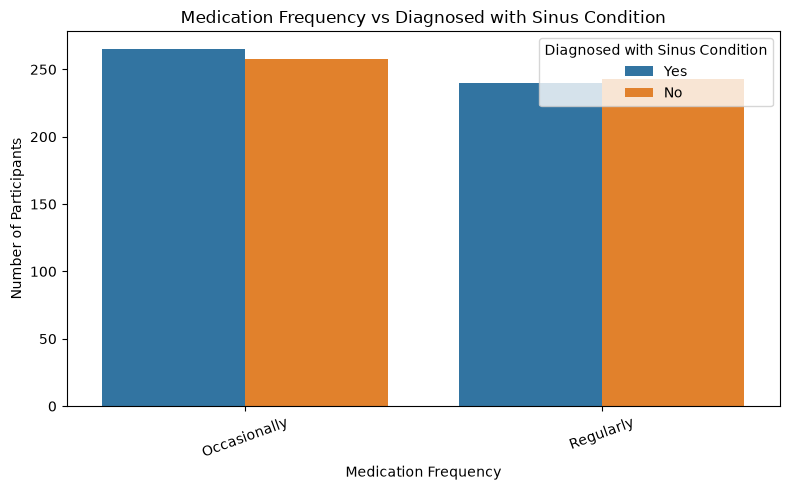




CHI-SQUARE TEST SUMMARY
                      Feature  Chi-square  p-value  Degrees of Freedom
                       Gender      0.4788   0.4890                   1
         Regular Sinus Issues      0.0000   0.9972                   1
      Most Problematic Season      0.6874   0.4071                   1
Triggered by External Factors      3.4003   0.0652                   1
                Known Allergy      0.3964   0.5290                   1
 Doctor Consulted (Past Year)      0.0968   0.7556                   1
     Headaches or Facial Pain      0.6678   0.4138                   1
         Medication Frequency      0.0612   0.8046                   1



AGE vs DIAGNOSED WITH SINUS CONDITION

Age statistics by diagnosis:
                                count   mean  median    std  min  max
Diagnosed with Sinus Condition                                       
No                                501  41.94    42.0  13.97   18   65
Yes                               505  41.12    40.0 

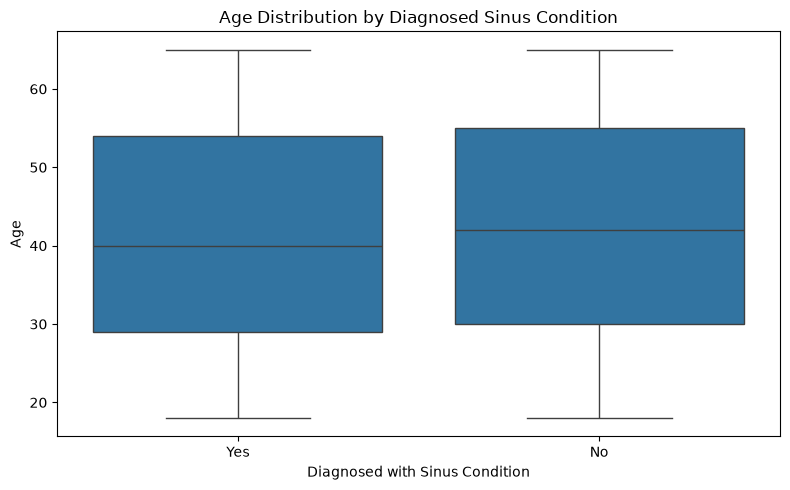




SINUS SEVERITY vs DIAGNOSED WITH SINUS CONDITION

Severity statistics by diagnosis:
                                count  mean  median   std  min  max
Diagnosed with Sinus Condition                                     
No                                501  2.92     3.0  1.44    1    5
Yes                               505  2.98     3.0  1.45    1    5


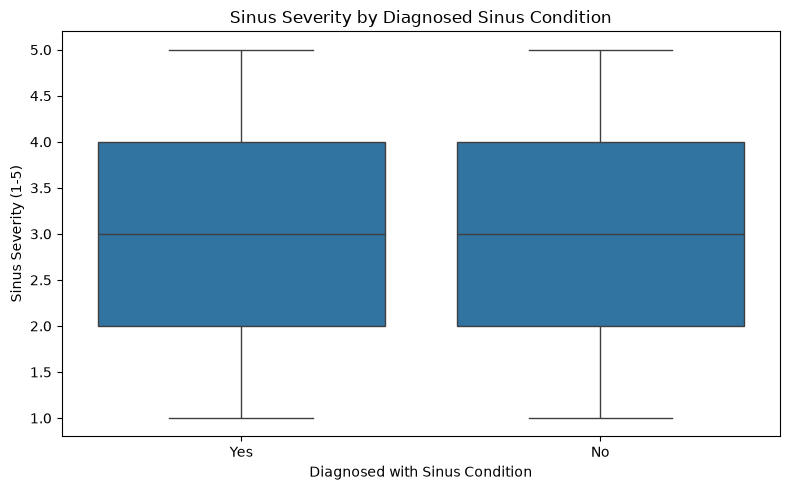

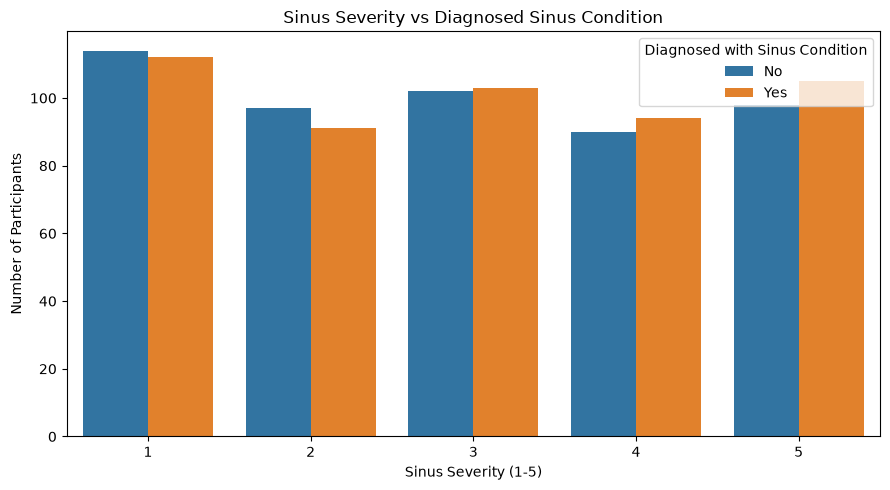


BIVARIATE EDA COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# BIVARIATE EDA: FEATURES vs DIAGNOSED SINUS CONDITION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Target variable
target = 'Diagnosed with Sinus Condition'

# ------------------------------------------------------------
# 1. CATEGORICAL FEATURES
# ------------------------------------------------------------

categorical_features = [
    'Gender',
    'Regular Sinus Issues',
    'Most Problematic Season',
    'Triggered by External Factors',
    'Known Allergy',
    'Doctor Consulted (Past Year)',
    'Headaches or Facial Pain',
    'Medication Frequency'
]

# Store statistical results
chi_square_results = []

for feature in categorical_features:

    print("\n" + "=" * 70)
    print(f"{feature} vs {target}")
    print("=" * 70)

    # Cross-tabulation: counts
    table = pd.crosstab(
        df[feature],
        df[target]
    )

    print("\nCOUNT TABLE:")
    print(table)

    # Row-wise percentages
    percentage_table = pd.crosstab(
        df[feature],
        df[target],
        normalize='index'
    ) * 100

    print("\nROW-WISE PERCENTAGE TABLE:")
    print(percentage_table.round(2))

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    print("\nCHI-SQUARE TEST:")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p:.4f}")
    print(f"Degrees of freedom: {dof}")

    if p < 0.05:
        print("Result: Statistically significant association (p < 0.05)")
    else:
        print("Result: No statistically significant association (p >= 0.05)")

    # Save result
    chi_square_results.append({
        'Feature': feature,
        'Chi-square': chi2,
        'p-value': p,
        'Degrees of Freedom': dof
    })

    # --------------------------------------------------------
    # Graph
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue=target
    )

    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel('Number of Participants')
    plt.xticks(rotation=20)
    plt.legend(title=target)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 2. CHI-SQUARE SUMMARY TABLE
# ------------------------------------------------------------

chi_square_summary = pd.DataFrame(chi_square_results)

print("\n\n")
print("=" * 70)
print("CHI-SQUARE TEST SUMMARY")
print("=" * 70)

print(
    chi_square_summary.round({
        'Chi-square': 4,
        'p-value': 4
    }).to_string(index=False)
)


# ------------------------------------------------------------
# 3. AGE vs DIAGNOSIS
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("AGE vs DIAGNOSED WITH SINUS CONDITION")
print("=" * 70)

print("\nAge statistics by diagnosis:")

age_summary = df.groupby(target)['Age'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

print(age_summary.round(2))


# Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x=target,
    y='Age'
)

plt.title('Age Distribution by Diagnosed Sinus Condition')
plt.xlabel(target)
plt.ylabel('Age')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. SINUS SEVERITY vs DIAGNOSIS
# ------------------------------------------------------------

print("\n\n")
print("=" * 70)
print("SINUS SEVERITY vs DIAGNOSED WITH SINUS CONDITION")
print("=" * 70)

severity_summary = df.groupby(target)['Sinus Severity (1-5)'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

print("\nSeverity statistics by diagnosis:")

print(severity_summary.round(2))


# Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x=target,
    y='Sinus Severity (1-5)'
)

plt.title('Sinus Severity by Diagnosed Sinus Condition')
plt.xlabel(target)
plt.ylabel('Sinus Severity (1-5)')

plt.tight_layout()
plt.show()


# Severity count plot

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Sinus Severity (1-5)',
    hue=target
)

plt.title('Sinus Severity vs Diagnosed Sinus Condition')
plt.xlabel('Sinus Severity (1-5)')
plt.ylabel('Number of Participants')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BIVARIATE EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

In [ ]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)

# Check missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

Duplicate rows: 6
Original dataset shape: (1006, 11)
Clean dataset shape: (1000, 11)

Missing values:
Age                               0
Gender                            0
Regular Sinus Issues              0
Most Problematic Season           0
Triggered by External Factors     0
Known Allergy                     0
Doctor Consulted (Past Year)      0
Sinus Severity (1-5)              0
Diagnosed with Sinus Condition    0
Headaches or Facial Pain          0
Medication Frequency              0
dtype: int64


In [ ]:
# Separate features (X) and target (y)

X = df_clean.drop('Diagnosed with Sinus Condition', axis=1)
y = df_clean['Diagnosed with Sinus Condition']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

X shape: (1000, 10)
y shape: (1000,)

Features:
['Age', 'Gender', 'Regular Sinus Issues', 'Most Problematic Season', 'Triggered by External Factors', 'Known Allergy', 'Doctor Consulted (Past Year)', 'Sinus Severity (1-5)', 'Headaches or Facial Pain', 'Medication Frequency']

Target:
Diagnosed with Sinus Condition
Yes    502
No     498
Name: count, dtype: int64


In [ ]:
# Identify numerical and categorical features

numerical_features = [
    'Age',
    'Sinus Severity (1-5)'
]

categorical_features = [
    'Gender',
    'Regular Sinus Issues',
    'Most Problematic Season',
    'Triggered by External Factors',
    'Known Allergy',
    'Doctor Consulted (Past Year)',
    'Headaches or Facial Pain',
    'Medication Frequency'
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Sinus Severity (1-5)']

Categorical features:
['Gender', 'Regular Sinus Issues', 'Most Problematic Season', 'Triggered by External Factors', 'Known Allergy', 'Doctor Consulted (Past Year)', 'Headaches or Facial Pain', 'Medication Frequency']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 10)
X_test : (200, 10)
y_train: (800,)
y_test : (200,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create pipeline
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred = logistic_model.predict(X_test)

# Probability predictions for ROC-AUC
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

# Convert Yes/No to binary for ROC-AUC
y_test_binary = (y_test == 'Yes').astype(int)

roc_auc = roc_auc_score(y_test_binary, y_prob)

# Print results
print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['No', 'Yes']
)

print(cm)

LOGISTIC REGRESSION RESULTS
Accuracy : 0.4950
Precision: 0.4952
Recall   : 0.5200
F1-Score : 0.5073
ROC-AUC  : 0.4950

Classification Report:
              precision    recall  f1-score   support

          No       0.49      0.47      0.48       100
         Yes       0.50      0.52      0.51       100

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200

Confusion Matrix:
[[47 53]
 [48 52]]


In [ ]:
# ============================================================
# MODEL 2: DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Decision Tree pipeline
decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

# Train
decision_tree_model.fit(X_train, y_train)

# Predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Probabilities
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    pos_label='Yes'
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    pos_label='Yes'
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    pos_label='Yes'
)

y_test_binary = (y_test == 'Yes').astype(int)

roc_auc_dt = roc_auc_score(
    y_test_binary,
    y_prob_dt
)

# Results
print("=" * 60)
print("DECISION TREE RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=['No', 'Yes']
)

print(cm_dt)

DECISION TREE RESULTS
Accuracy : 0.4900
Precision: 0.4923
Recall   : 0.6400
F1-Score : 0.5565
ROC-AUC  : 0.5319

Classification Report:
              precision    recall  f1-score   support

          No       0.49      0.34      0.40       100
         Yes       0.49      0.64      0.56       100

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.48       200
weighted avg       0.49      0.49      0.48       200

Confusion Matrix:
[[34 66]
 [36 64]]


In [ ]:
# ============================================================
# MODEL 3: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Random Forest pipeline
random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test)

# Probabilities
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label='Yes'
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label='Yes'
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    pos_label='Yes'
)

y_test_binary = (y_test == 'Yes').astype(int)

roc_auc_rf = roc_auc_score(
    y_test_binary,
    y_prob_rf
)

# Results
print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=['No', 'Yes']
)

print(cm_rf)

RANDOM FOREST RESULTS
Accuracy : 0.4800
Precision: 0.4804
Recall   : 0.4900
F1-Score : 0.4851
ROC-AUC  : 0.4570

Classification Report:
              precision    recall  f1-score   support

          No       0.48      0.47      0.47       100
         Yes       0.48      0.49      0.49       100

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.48      0.48       200

Confusion Matrix:
[[47 53]
 [51 49]]


In [ ]:
# ============================================================
# MODEL 4: SUPPORT VECTOR MACHINE
# ============================================================

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create SVM pipeline
svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ))
])

# Train
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Probabilities
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    pos_label='Yes'
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    pos_label='Yes'
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    pos_label='Yes'
)

y_test_binary = (y_test == 'Yes').astype(int)

roc_auc_svm = roc_auc_score(
    y_test_binary,
    y_prob_svm
)

# Results
print("=" * 60)
print("SUPPORT VECTOR MACHINE RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_auc_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=['No', 'Yes']
)

print(cm_svm)

c:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SUPPORT VECTOR MACHINE RESULTS
Accuracy : 0.4800
Precision: 0.4808
Recall   : 0.5000
F1-Score : 0.4902
ROC-AUC  : 0.5000

Classification Report:
              precision    recall  f1-score   support

          No       0.48      0.46      0.47       100
         Yes       0.48      0.50      0.49       100

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.48      0.48       200

Confusion Matrix:
[[46 54]
 [50 50]]


In [ ]:
# ============================================================
# MODEL 5: XGBOOST
# ============================================================

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create XGBoost pipeline
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

# Train
xgb_model.fit(X_train, (y_train == 'Yes').astype(int))

# Predictions
y_pred_xgb_binary = xgb_model.predict(X_test)

# Probability
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Convert predictions back to Yes/No
y_pred_xgb = pd.Series(
    y_pred_xgb_binary,
    index=y_test.index
).map({
    0: 'No',
    1: 'Yes'
})

# Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    pos_label='Yes'
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    pos_label='Yes'
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    pos_label='Yes'
)

roc_auc_xgb = roc_auc_score(
    (y_test == 'Yes').astype(int),
    y_prob_xgb
)

print("=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb,
    labels=['No', 'Yes']
)

print(cm_xgb)

XGBOOST RESULTS
Accuracy : 0.4750
Precision: 0.4737
Recall   : 0.4500
F1-Score : 0.4615
ROC-AUC  : 0.4660

Classification Report:
              precision    recall  f1-score   support

          No       0.48      0.50      0.49       100
         Yes       0.47      0.45      0.46       100

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200

Confusion Matrix:
[[50 50]
 [55 45]]



LOGISTIC REGRESSION
Accuracy : 0.4950
Precision: 0.4952
Recall   : 0.5200
F1-Score : 0.5073
ROC-AUC  : 0.4950

Confusion Matrix:
[[47 53]
 [48 52]]

DECISION TREE
Accuracy : 0.4900
Precision: 0.4923
Recall   : 0.6400
F1-Score : 0.5565
ROC-AUC  : 0.5319

Confusion Matrix:
[[34 66]
 [36 64]]

RANDOM FOREST
Accuracy : 0.4800
Precision: 0.4804
Recall   : 0.4900
F1-Score : 0.4851
ROC-AUC  : 0.4570

Confusion Matrix:
[[47 53]
 [51 49]]

SVM


c:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.4800
Precision: 0.4808
Recall   : 0.5000
F1-Score : 0.4902
ROC-AUC  : 0.5000

Confusion Matrix:
[[46 54]
 [50 50]]

XGBOOST
Accuracy : 0.4750
Precision: 0.4737
Recall   : 0.4500
F1-Score : 0.4615
ROC-AUC  : 0.4660

Confusion Matrix:
[[50 50]
 [55 45]]

CATBOOST
Accuracy : 0.4650
Precision: 0.4653
Recall   : 0.4700
F1-Score : 0.4677
ROC-AUC  : 0.4612

Confusion Matrix:
[[46 54]
 [53 47]]



FINAL MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Decision Tree     0.490     0.4923    0.64    0.5565   0.5318
Logistic Regression     0.495     0.4952    0.52    0.5073   0.4950
                SVM     0.480     0.4808    0.50    0.4902   0.5000
      Random Forest     0.480     0.4804    0.49    0.4851   0.4570
           CatBoost     0.465     0.4653    0.47    0.4677   0.4612
            XGBoost     0.475     0.4737    0.45    0.4615   0.4660



MODEL COMPARISON — PERCENTAGES
              Model  Accuracy  Precision  Recall  F1-Score  R

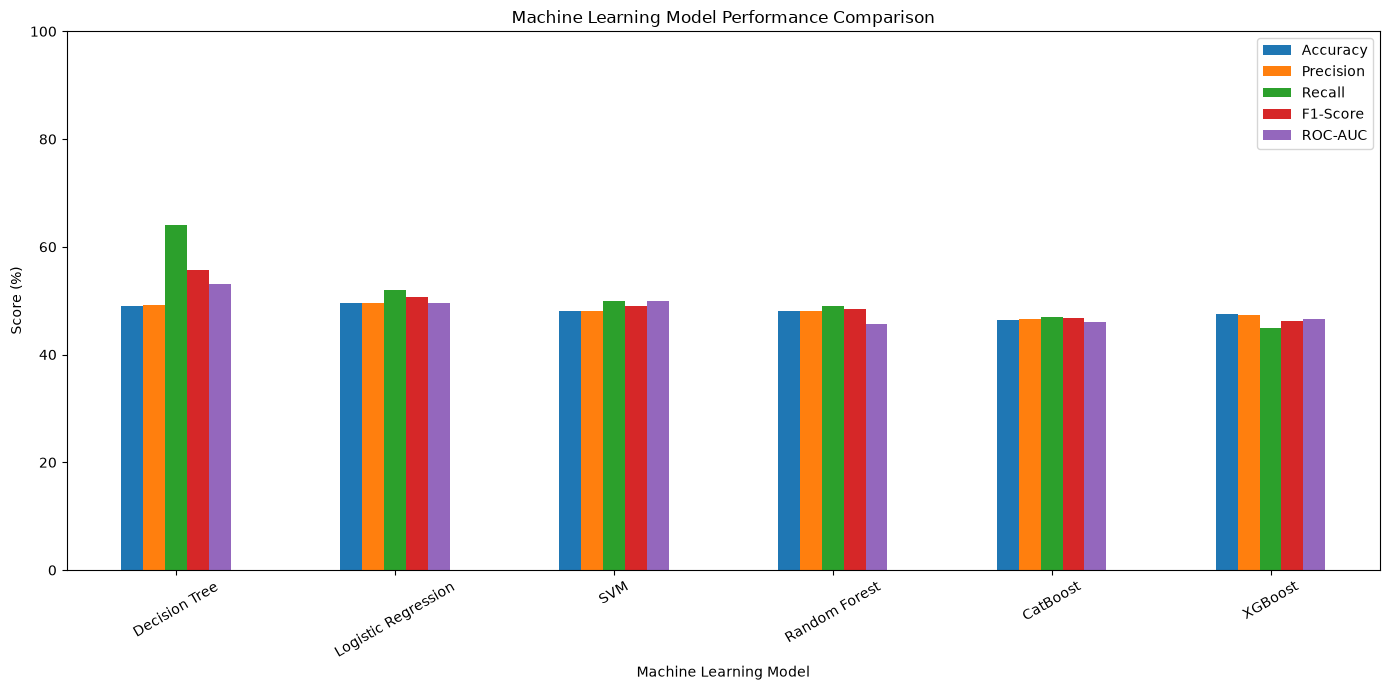

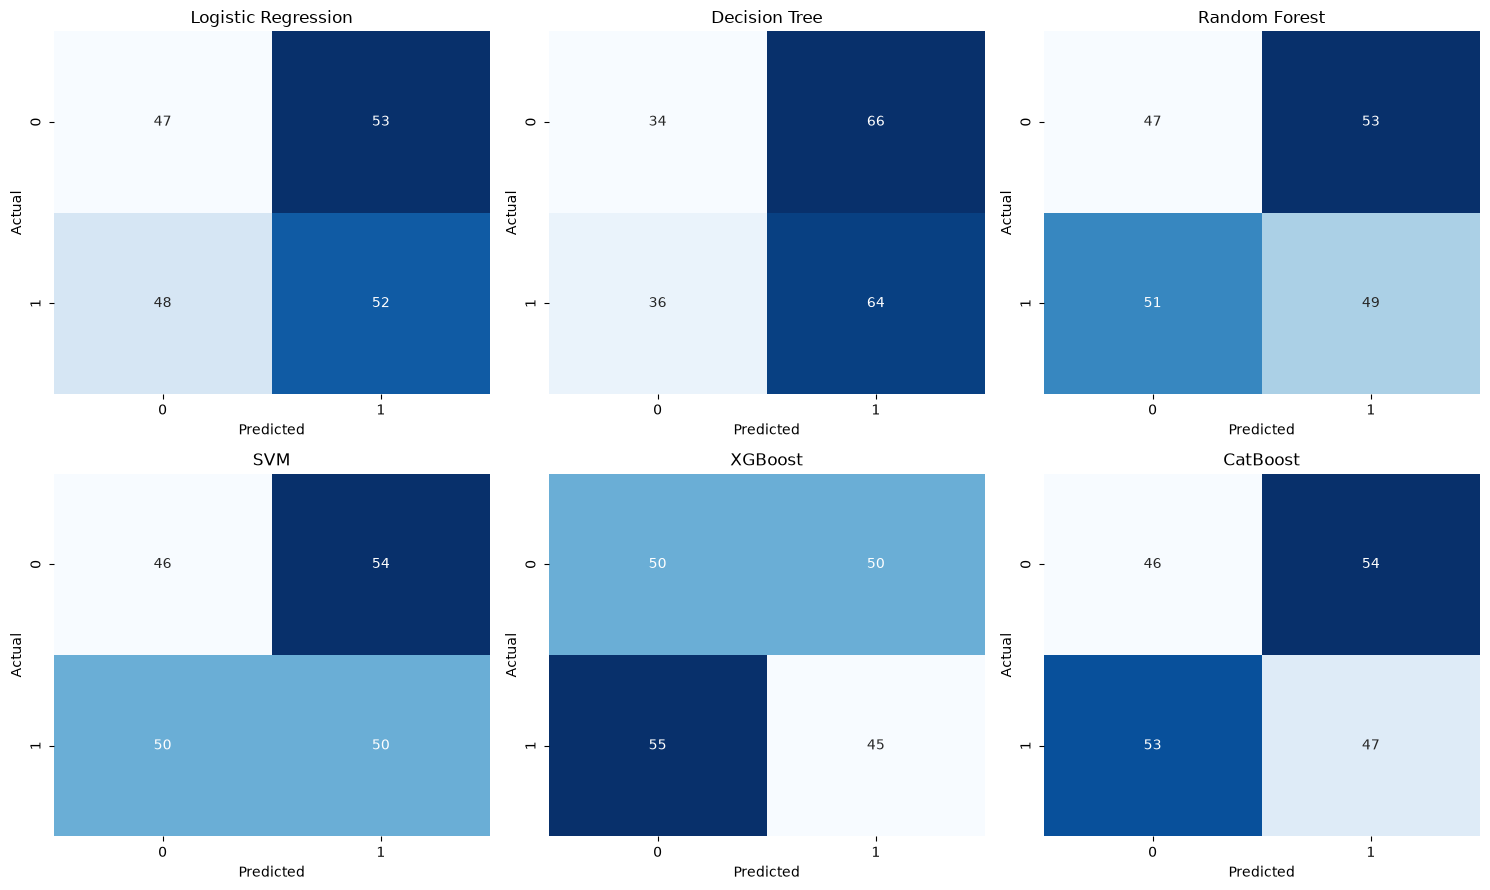



COMPLETE ML EXPERIMENT FINISHED


In [ ]:
# ============================================================
# COMPLETE ML EXPERIMENT
# Logistic Regression
# Decision Tree
# Random Forest
# SVM
# XGBoost
# CatBoost
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ============================================================
# 1. DATA
# ============================================================

# Use the cleaned dataset
X = df_clean.drop('Diagnosed with Sinus Condition', axis=1)
y = df_clean['Diagnosed with Sinus Condition']


# ============================================================
# 2. FEATURE TYPES
# ============================================================

numerical_features = [
    'Age',
    'Sinus Severity (1-5)'
]

categorical_features = [
    'Gender',
    'Regular Sinus Issues',
    'Most Problematic Season',
    'Triggered by External Factors',
    'Known Allergy',
    'Doctor Consulted (Past Year)',
    'Headaches or Facial Pain',
    'Medication Frequency'
]


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)


# ============================================================
# 5. DEFINE MODELS
# ============================================================

models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),

    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ),

    'CatBoost': CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        verbose=0,
        random_seed=42
    )
}


# ============================================================
# 6. TRAIN AND EVALUATE ALL MODELS
# ============================================================

results = []
confusion_matrices = {}
trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    # XGBoost and CatBoost require numeric target
    if name in ['XGBoost', 'CatBoost']:

        y_train_model = (y_train == 'Yes').astype(int)
        y_test_model = (y_test == 'Yes').astype(int)

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train_model)

        predictions = pipeline.predict(X_test)
        probabilities = pipeline.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(
            y_test_model,
            predictions
        )

        precision = precision_score(
            y_test_model,
            predictions
        )

        recall = recall_score(
            y_test_model,
            predictions
        )

        f1 = f1_score(
            y_test_model,
            predictions
        )

        roc_auc = roc_auc_score(
            y_test_model,
            probabilities
        )

        cm = confusion_matrix(
            y_test_model,
            predictions
        )

    else:

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)
        probabilities = pipeline.predict_proba(X_test)[:, 1]

        y_test_binary = (y_test == 'Yes').astype(int)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        precision = precision_score(
            y_test,
            predictions,
            pos_label='Yes'
        )

        recall = recall_score(
            y_test,
            predictions,
            pos_label='Yes'
        )

        f1 = f1_score(
            y_test,
            predictions,
            pos_label='Yes'
        )

        roc_auc = roc_auc_score(
            y_test_binary,
            probabilities
        )

        cm = confusion_matrix(
            y_test,
            predictions,
            labels=['No', 'Yes']
        )

    # Save results

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    confusion_matrices[name] = cm
    trained_models[name] = pipeline

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)


# ============================================================
# 7. MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

print("\n\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(
    results_df.round(4).to_string(index=False)
)


# ============================================================
# 8. PERCENTAGE VERSION
# ============================================================

percentage_results = results_df.copy()

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

percentage_results[metric_columns] = (
    percentage_results[metric_columns] * 100
)

print("\n\n")
print("=" * 80)
print("MODEL COMPARISON — PERCENTAGES")
print("=" * 80)

print(
    percentage_results.round(2).to_string(index=False)
)


# ============================================================
# 9. PERFORMANCE GRAPH
# ============================================================

plot_df = percentage_results.set_index('Model')

plot_df[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Machine Learning Model Performance Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 10. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, (name, cm) in zip(
    axes,
    confusion_matrices.items()
):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


print("\n")
print("=" * 80)
print("COMPLETE ML EXPERIMENT FINISHED")
print("=" * 80)

Target distribution:
Diagnosed with Sinus Condition
1    502
0    498
Name: count, dtype: int64

5-FOLD STRATIFIED CROSS-VALIDATION

Logistic Regression
--------------------------------------------------
Accuracy : 0.4840 ± 0.0258
Precision: 0.4857 ± 0.0259
Recall   : 0.4940 ± 0.0483
F1-Score : 0.4893 ± 0.0349
ROC-AUC  : 0.4817 ± 0.0334

Decision Tree
--------------------------------------------------
Accuracy : 0.4960 ± 0.0323
Precision: 0.4981 ± 0.0331
Recall   : 0.4424 ± 0.0343
F1-Score : 0.4683 ± 0.0324
ROC-AUC  : 0.4944 ± 0.0183

Random Forest
--------------------------------------------------
Accuracy : 0.4890 ± 0.0229
Precision: 0.4917 ± 0.0206
Recall   : 0.4881 ± 0.0068
F1-Score : 0.4897 ± 0.0130
ROC-AUC  : 0.4782 ± 0.0297

SVM
--------------------------------------------------
Accuracy : 0.5080 ± 0.0133
Precision: 0.5088 ± 0.0122
Recall   : 0.5697 ± 0.0407
F1-Score : 0.5370 ± 0.0223
ROC-AUC  : 0.5165 ± 0.0098

XGBoost
--------------------------------------------------
Accuracy

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
3,SVM,50.8,1.33,50.88,56.97,53.70,51.65
2,Random Forest,48.9,2.29,49.17,48.81,48.97,47.82
0,Logistic Regression,48.4,2.58,48.57,49.40,48.93,48.17
5,CatBoost,48.5,2.55,48.73,48.41,48.56,46.91
4,XGBoost,47.5,2.00,47.64,47.81,47.67,45.96
1,Decision Tree,49.6,3.23,49.81,44.24,46.83,49.44


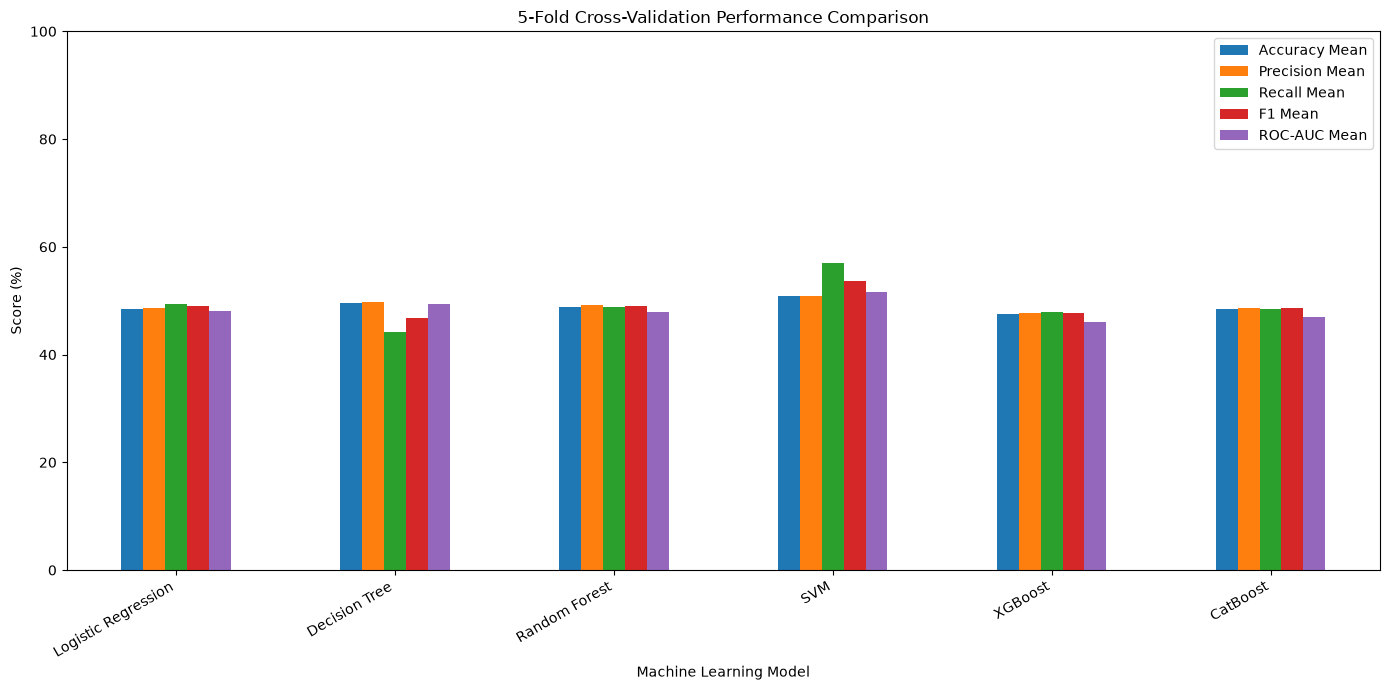


Cross-validation results saved as:
cross_validation_results.csv

5-FOLD CROSS-VALIDATION COMPLETED.


In [ ]:
# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# Sinus Condition Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ------------------------------------------------------------
# 1. Prepare target
# ------------------------------------------------------------

# Convert Yes/No target to 1/0
y_binary = (y == 'Yes').astype(int)

print("Target distribution:")
print(y_binary.value_counts())
print()


# ------------------------------------------------------------
# 2. Features
# ------------------------------------------------------------

numerical_features = [
    'Age',
    'Sinus Severity (1-5)'
]

categorical_features = [
    'Gender',
    'Regular Sinus Issues',
    'Most Problematic Season',
    'Triggered by External Factors',
    'Known Allergy',
    'Doctor Consulted (Past Year)',
    'Headaches or Facial Pain',
    'Medication Frequency'
]


# ------------------------------------------------------------
# 3. Preprocessing
# ------------------------------------------------------------

preprocessor_cv = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 4. Define Models
# ------------------------------------------------------------

models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),

    'SVM': CalibratedClassifierCV(
        SVC(
            kernel='rbf',
            random_state=42
        ),
        cv=3,
        method='sigmoid'
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ),

    'CatBoost': CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        verbose=0,
        random_seed=42
    )
}


# ------------------------------------------------------------
# 5. 5-Fold Stratified Cross-Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


cv_results = []


print("=" * 75)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 75)


for model_name, model in models.items():

    pipeline = Pipeline([
        ('preprocessing', preprocessor_cv),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_binary,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    result = {
        'Model': model_name,

        'Accuracy Mean': scores['test_accuracy'].mean(),
        'Accuracy Std': scores['test_accuracy'].std(),

        'Precision Mean': scores['test_precision'].mean(),
        'Precision Std': scores['test_precision'].std(),

        'Recall Mean': scores['test_recall'].mean(),
        'Recall Std': scores['test_recall'].std(),

        'F1 Mean': scores['test_f1'].mean(),
        'F1 Std': scores['test_f1'].std(),

        'ROC-AUC Mean': scores['test_roc_auc'].mean(),
        'ROC-AUC Std': scores['test_roc_auc'].std()
    }

    cv_results.append(result)

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"Accuracy : {result['Accuracy Mean']:.4f} ± {result['Accuracy Std']:.4f}")
    print(f"Precision: {result['Precision Mean']:.4f} ± {result['Precision Std']:.4f}")
    print(f"Recall   : {result['Recall Mean']:.4f} ± {result['Recall Std']:.4f}")
    print(f"F1-Score : {result['F1 Mean']:.4f} ± {result['F1 Std']:.4f}")
    print(f"ROC-AUC  : {result['ROC-AUC Mean']:.4f} ± {result['ROC-AUC Std']:.4f}")


# ------------------------------------------------------------
# 6. Create Results Table
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

cv_results_percentage = cv_results_df.copy()

percentage_columns = [
    'Accuracy Mean',
    'Accuracy Std',
    'Precision Mean',
    'Precision Std',
    'Recall Mean',
    'Recall Std',
    'F1 Mean',
    'F1 Std',
    'ROC-AUC Mean',
    'ROC-AUC Std'
]

for col in percentage_columns:
    cv_results_percentage[col] = (
        cv_results_percentage[col] * 100
    ).round(2)


# ------------------------------------------------------------
# 7. Display Final CV Table
# ------------------------------------------------------------

print("\n")
print("=" * 100)
print("5-FOLD CROSS-VALIDATION RESULTS (%)")
print("=" * 100)

display(
    cv_results_percentage[
        [
            'Model',
            'Accuracy Mean',
            'Accuracy Std',
            'Precision Mean',
            'Recall Mean',
            'F1 Mean',
            'ROC-AUC Mean'
        ]
    ].sort_values(
        by='F1 Mean',
        ascending=False
    )
)


# ------------------------------------------------------------
# 8. Performance Comparison Graph
# ------------------------------------------------------------

plot_df = cv_results_percentage[
    [
        'Model',
        'Accuracy Mean',
        'Precision Mean',
        'Recall Mean',
        'F1 Mean',
        'ROC-AUC Mean'
    ]
].copy()

plot_df = plot_df.set_index('Model')

plot_df.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title(
    '5-Fold Cross-Validation Performance Comparison'
)

plt.xlabel(
    'Machine Learning Model'
)

plt.ylabel(
    'Score (%)'
)

plt.xticks(
    rotation=30,
    ha='right'
)

plt.ylim(0, 100)

plt.legend(
    loc='upper right'
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Save Results
# ------------------------------------------------------------

cv_results_percentage.to_csv(
    'cross_validation_results.csv',
    index=False
)

print("\nCross-validation results saved as:")
print("cross_validation_results.csv")

print("\n5-FOLD CROSS-VALIDATION COMPLETED.")

STEP 3: HYPERPARAMETER TUNING + FINAL MODEL EVALUATION

Target distribution:
Diagnosed with Sinus Condition
1    502
0    498
Name: count, dtype: int64

Training samples : 800
Testing samples  : 200


TUNING: Logistic Regression

Best CV F1:
0.4935

Best Parameters:
{'model__solver': 'liblinear', 'model__C': 0.01}

Status: COMPLETED


TUNING: Decision Tree

Best CV F1:
0.5202

Best Parameters:
{'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_depth': 5, 'model__criterion': 'entropy'}

Status: COMPLETED


TUNING: Random Forest

Best CV F1:
0.5078

Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 4}

Status: COMPLETED


TUNING: SVM

Best CV F1:
0.5498

Best Parameters:
{'model__estimator__gamma': 1, 'model__estimator__C': 0.01}

Status: COMPLETED


TUNING: XGBoost

Best CV F1:
0.5054

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'm

,Model,Best CV F1 (%),Best Parameters
0,Logistic Regression,49.35,"{'model__solver': 'liblinear', 'model__C': 0.01}"
1,Decision Tree,52.02,"{'model__min_samples_split': 5, 'model__min_sa..."
2,Random Forest,50.78,"{'model__n_estimators': 500, 'model__min_sampl..."
3,SVM,54.98,"{'model__estimator__gamma': 1, 'model__estimat..."
4,XGBoost,50.54,"{'model__subsample': 0.8, 'model__n_estimators..."
5,CatBoost,49.77,"{'model__learning_rate': 0.01, 'model__l2_leaf..."




FINAL TEST-SET EVALUATION

Evaluating: Logistic Regression
Accuracy=0.5100 | Precision=0.5093 | Recall=0.5500 | F1=0.5288 | ROC-AUC=0.4963

Evaluating: Decision Tree
Accuracy=0.4850 | Precision=0.4892 | Recall=0.6800 | F1=0.5690 | ROC-AUC=0.5368

Evaluating: Random Forest
Accuracy=0.4600 | Precision=0.4636 | Recall=0.5100 | F1=0.4857 | ROC-AUC=0.4612

Evaluating: SVM
Accuracy=0.5150 | Precision=0.5158 | Recall=0.4900 | F1=0.5026 | ROC-AUC=0.5094

Evaluating: XGBoost
Accuracy=0.4650 | Precision=0.4679 | Recall=0.5100 | F1=0.4880 | ROC-AUC=0.4797

Evaluating: CatBoost
Accuracy=0.4450 | Precision=0.4476 | Recall=0.4700 | F1=0.4585 | ROC-AUC=0.4704


FINAL MODEL PERFORMANCE (%)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,48.5,48.92,68.0,56.90,53.68
0,Logistic Regression,51.0,50.93,55.0,52.88,49.63
3,SVM,51.5,51.58,49.0,50.26,50.94
4,XGBoost,46.5,46.79,51.0,48.80,47.97
2,Random Forest,46.0,46.36,51.0,48.57,46.12
5,CatBoost,44.5,44.76,47.0,45.85,47.04


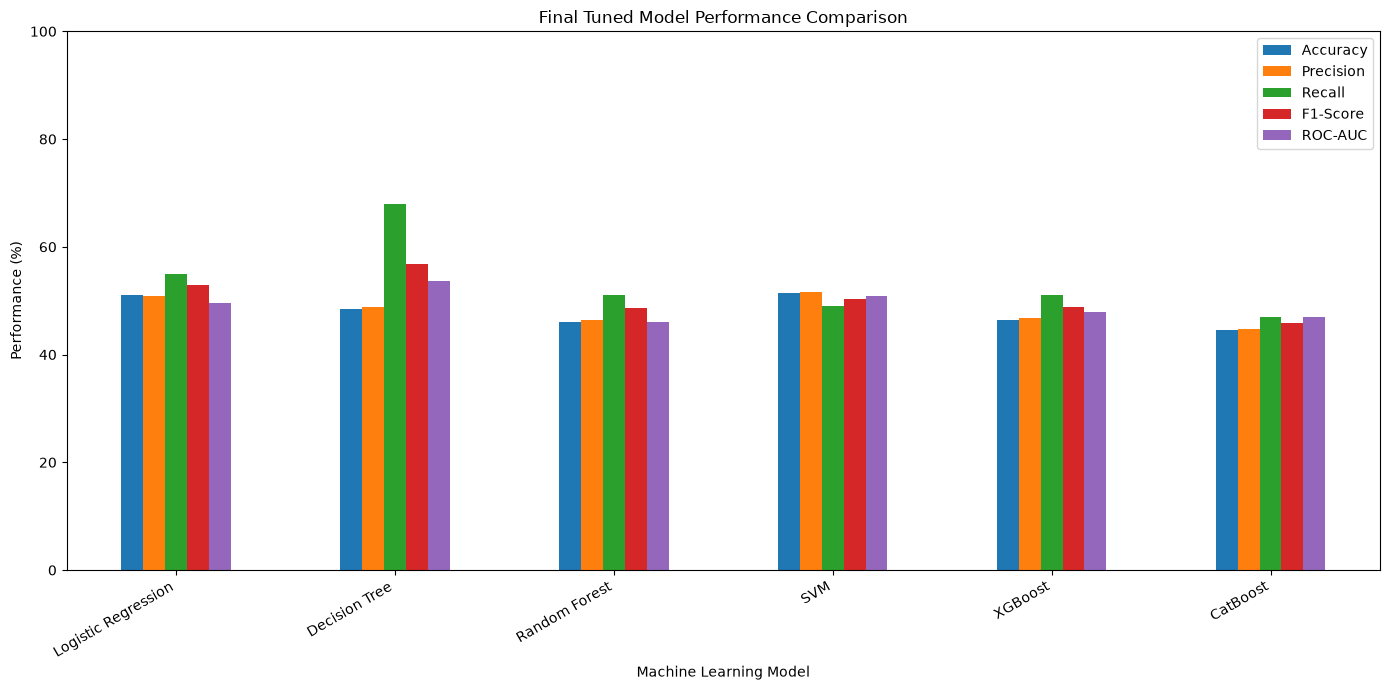

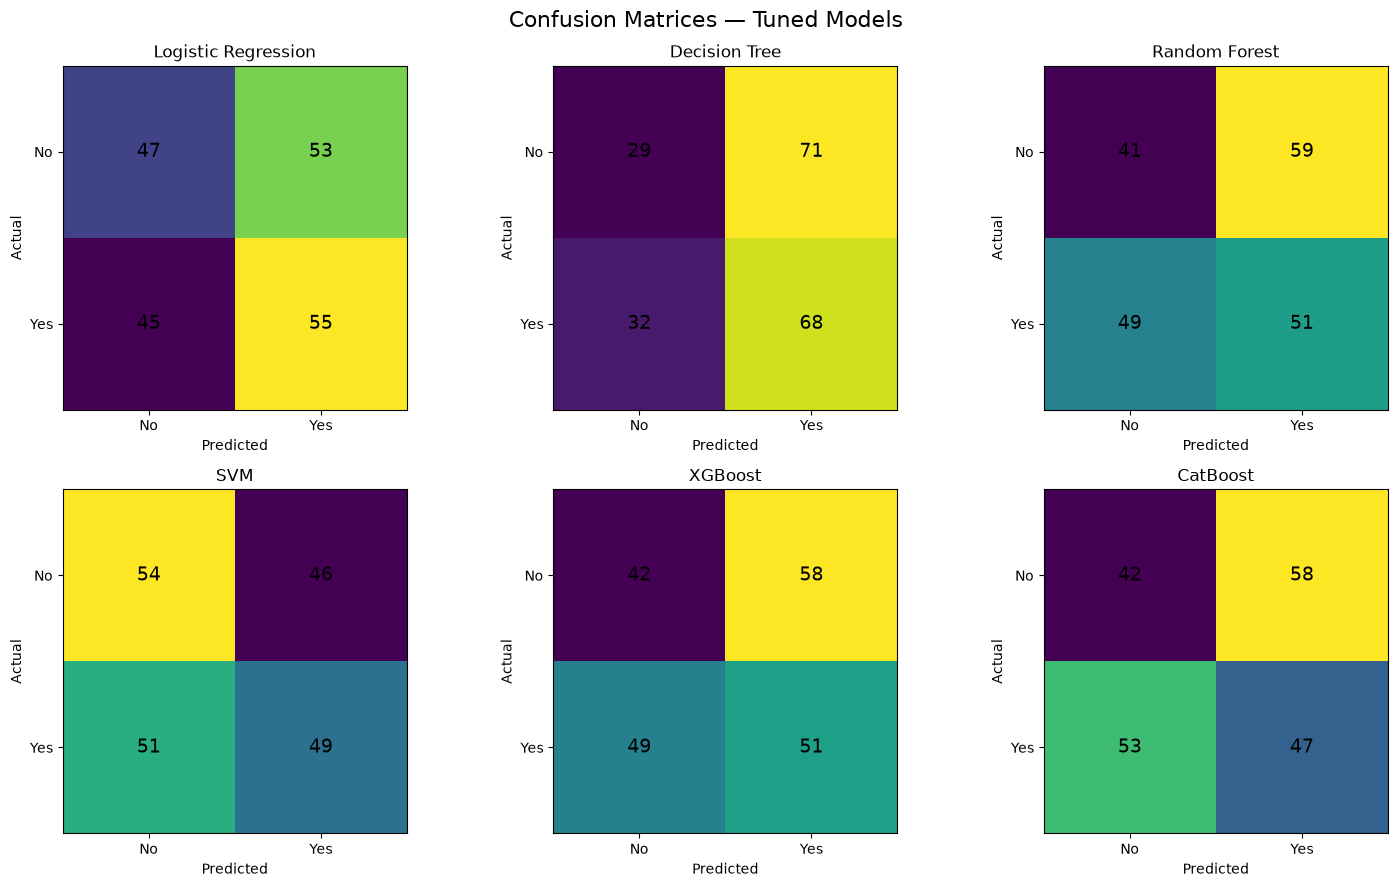

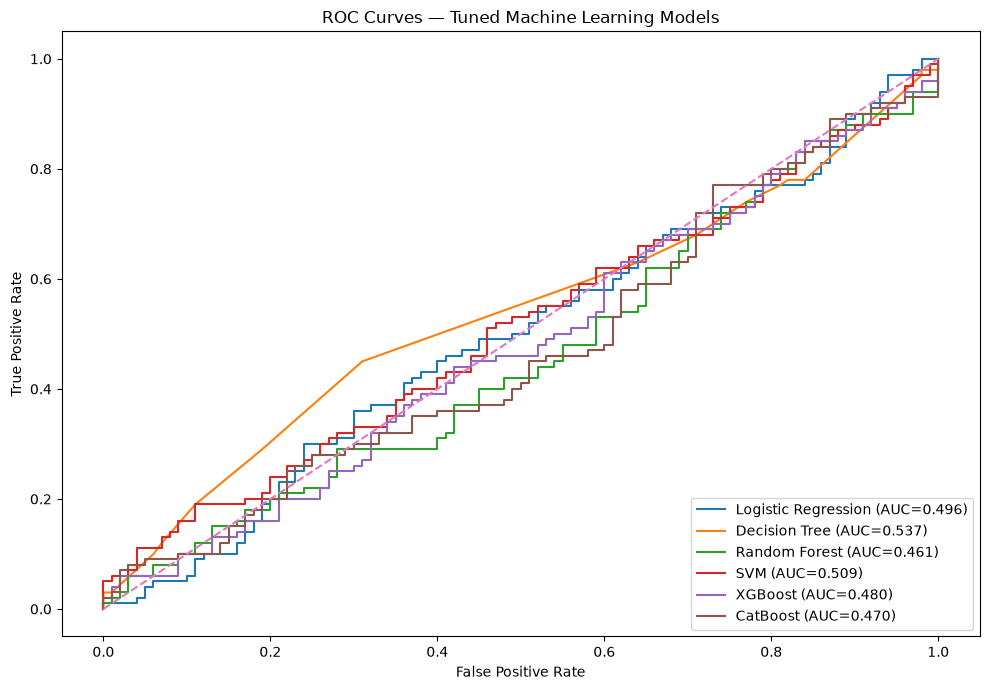



MODEL SELECTED FOR EXPLAINABILITY
Selected model: Decision Tree

Calculating permutation importance...


ValueError: All arrays must be of the same length

In [ ]:
# ============================================================
# STEP 3 — HYPERPARAMETER TUNING + FINAL EVALUATION
# CORRECTED VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")


# ============================================================
# STEP 3 START
# ============================================================

print("=" * 80)
print("STEP 3: HYPERPARAMETER TUNING + FINAL MODEL EVALUATION")
print("=" * 80)


# ============================================================
# 1. TARGET
# ============================================================

y_binary = (y == 'Yes').astype(int)

print("\nTarget distribution:")
print(y_binary.value_counts())


# ============================================================
# 2. FEATURES
# ============================================================

numerical_features = [
    'Age',
    'Sinus Severity (1-5)'
]

categorical_features = [
    'Gender',
    'Regular Sinus Issues',
    'Most Problematic Season',
    'Triggered by External Factors',
    'Known Allergy',
    'Doctor Consulted (Past Year)',
    'Headaches or Facial Pain',
    'Medication Frequency'
]


# ============================================================
# 3. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("\nTraining samples :", len(X_train_final))
print("Testing samples  :", len(X_test_final))


# ============================================================
# 5. CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 6. MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "SVM": CalibratedClassifierCV(
        SVC(
            kernel="rbf",
            random_state=42
        ),
        cv=3
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_seed=42
    )
}


# ============================================================
# 7. HYPERPARAMETER SEARCH SPACES
# ============================================================

param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 4, 6, 8, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },

    "SVM": {
        "model__estimator__C": [0.01, 0.1, 1, 10, 100],
        "model__estimator__gamma": [
            "scale",
            "auto",
            0.001,
            0.01,
            0.1,
            1
        ]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
    },

    "CatBoost": {
        "model__iterations": [100, 200, 300, 500],
        "model__depth": [3, 4, 5, 6, 7],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__l2_leaf_reg": [1, 3, 5, 7, 10]
    }
}


# ============================================================
# 8. HYPERPARAMETER TUNING
# ============================================================

tuned_models = {}
tuning_results = []


for model_name in models:

    print("\n")
    print("=" * 80)
    print(f"TUNING: {model_name}")
    print("=" * 80)

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", models[model_name])
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[model_name],
        n_iter=15,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    search.fit(
        X_train_final,
        y_train_final
    )

    tuned_models[model_name] = search.best_estimator_

    tuning_results.append({
        "Model": model_name,
        "Best CV F1": search.best_score_,
        "Best Parameters": str(search.best_params_)
    })

    # CORRECT ATTRIBUTE: best_params_
    print("\nBest CV F1:")
    print(round(search.best_score_, 4))

    print("\nBest Parameters:")
    print(search.best_params_)

    print("\nStatus: COMPLETED")


# ============================================================
# 9. TUNING SUMMARY
# ============================================================

tuning_df = pd.DataFrame(
    tuning_results
)

tuning_df["Best CV F1 (%)"] = (
    tuning_df["Best CV F1"] * 100
).round(2)


print("\n")
print("=" * 100)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 100)

display(
    tuning_df[
        [
            "Model",
            "Best CV F1 (%)",
            "Best Parameters"
        ]
    ]
)


# ============================================================
# 10. FINAL TEST SET EVALUATION
# ============================================================

final_results = []

predictions = {}
probabilities = {}


print("\n")
print("=" * 100)
print("FINAL TEST-SET EVALUATION")
print("=" * 100)


for model_name, model in tuned_models.items():

    print(f"\nEvaluating: {model_name}")

    model.fit(
        X_train_final,
        y_train_final
    )

    y_pred = model.predict(
        X_test_final
    )

    y_prob = model.predict_proba(
        X_test_final
    )[:, 1]

    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    accuracy = accuracy_score(
        y_test_final,
        y_pred
    )

    precision = precision_score(
        y_test_final,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_final,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_final,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_final,
        y_prob
    )

    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    print(
        f"Accuracy={accuracy:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f} | "
        f"ROC-AUC={roc_auc:.4f}"
    )


# ============================================================
# 11. FINAL RESULTS TABLE
# ============================================================

final_results_df = pd.DataFrame(
    final_results
)

final_results_percentage = final_results_df.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]:

    final_results_percentage[col] = (
        final_results_percentage[col] * 100
    ).round(2)


print("\n")
print("=" * 100)
print("FINAL MODEL PERFORMANCE (%)")
print("=" * 100)

display(
    final_results_percentage.sort_values(
        by="F1-Score",
        ascending=False
    )
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

final_results_percentage.to_csv(
    "final_model_results.csv",
    index=False
)

tuning_df.to_csv(
    "hyperparameter_tuning_results.csv",
    index=False
)


# ============================================================
# 13. FINAL PERFORMANCE GRAPH
# ============================================================

plot_df = final_results_percentage.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Final Tuned Model Performance Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Performance (%)"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.savefig(
    "final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()


for i, model_name in enumerate(tuned_models.keys()):

    cm = confusion_matrix(
        y_test_final,
        predictions[model_name]
    )

    axes[i].imshow(cm)

    axes[i].set_title(
        model_name
    )

    axes[i].set_xlabel(
        "Predicted"
    )

    axes[i].set_ylabel(
        "Actual"
    )

    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])

    axes[i].set_xticklabels(
        ["No", "Yes"]
    )

    axes[i].set_yticklabels(
        ["No", "Yes"]
    )

    for row in range(2):

        for col in range(2):

            axes[i].text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
                fontsize=14
            )


plt.suptitle(
    "Confusion Matrices — Tuned Models",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "final_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. ROC CURVES
# ============================================================

plt.figure(
    figsize=(10, 7)
)


for model_name in tuned_models.keys():

    fpr, tpr, _ = roc_curve(
        y_test_final,
        probabilities[model_name]
    )

    auc_value = roc_auc_score(
        y_test_final,
        probabilities[model_name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_value:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves — Tuned Machine Learning Models"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "final_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. SELECT MODEL FOR EXPLAINABILITY
# ============================================================

best_model_name = final_results_df.loc[
    final_results_df["F1-Score"].idxmax(),
    "Model"
]

best_model = tuned_models[
    best_model_name
]


print("\n")
print("=" * 80)
print("MODEL SELECTED FOR EXPLAINABILITY")
print("=" * 80)

print(
    "Selected model:",
    best_model_name
)


# ============================================================
# 17. PERMUTATION IMPORTANCE
# ============================================================

print("\nCalculating permutation importance...")


perm = permutation_importance(
    best_model,
    X_test_final,
    y_test_final,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


feature_names = best_model.named_steps[
    "preprocessing"
].get_feature_names_out()


importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance Mean": perm.importances_mean,

    "Importance Std": perm.importances_std

})


importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)


print("\nTop 15 features:")

display(
    importance_df.head(15)
)


# ============================================================
# 18. FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = importance_df.head(
    15
).sort_values(
    by="Importance Mean"
)


plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"]
)

plt.xlabel(
    "Mean Permutation Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"Top Feature Importance — {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. SAVE FEATURE IMPORTANCE
# ============================================================

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)


# ============================================================
# 20. SAVE BEST MODEL
# ============================================================

joblib.dump(
    best_model,
    "best_sinus_condition_model.pkl"
)


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 80)
print(
    f"CLASSIFICATION REPORT — {best_model_name}"
)
print("=" * 80)

print(
    classification_report(
        y_test_final,
        predictions[best_model_name],
        target_names=[
            "No Diagnosis",
            "Diagnosis"
        ],
        zero_division=0
    )
)


# ============================================================
# 22. FINAL STATUS
# ============================================================

print("\n")
print("=" * 80)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
FILES GENERATED:

1. final_model_results.csv
2. hyperparameter_tuning_results.csv
3. final_model_comparison.png
4. final_confusion_matrices.png
5. final_roc_curves.png
6. feature_importance.csv
7. feature_importance.png
8. best_sinus_condition_model.pkl
""")

print("""
PROJECT PROGRESS:

Dataset                     ✅
EDA                         ✅
Data Cleaning               ✅
Preprocessing               ✅
Initial ML Models           ✅
5-Fold Cross-Validation     ✅
Hyperparameter Tuning       ✅
Final Evaluation            🔄
Confusion Matrices          🔄
ROC Curves                  🔄
Feature Importance          🔄
Literature Review           ⏳
Research Gap                ⏳
Final Report                ⏳
GitHub                      ⏳
""")

STEP 3 FINALIZATION — FEATURE IMPORTANCE

Final model performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,48.5,48.92,68.0,56.90,53.68
0,Logistic Regression,51.0,50.93,55.0,52.88,49.63
3,SVM,51.5,51.58,49.0,50.26,50.94
4,XGBoost,46.5,46.79,51.0,48.80,47.97
2,Random Forest,46.0,46.36,51.0,48.57,46.12
5,CatBoost,44.5,44.76,47.0,45.85,47.04




MODEL SELECTED FOR EXPLAINABILITY
Selected model: Decision Tree

Calculating permutation importance...

Number of original features: 10
Number of importance values: 10


PERMUTATION FEATURE IMPORTANCE


,Feature,Importance Mean,Importance Std
0,Age,0.036546,0.027483
9,Medication Frequency,0.009621,0.003426
1,Gender,0.000000,0.000000
3,Most Problematic Season,0.000000,0.000000
6,Doctor Consulted (Past Year),0.000000,0.000000
4,Triggered by External Factors,-0.000963,0.014797
5,Known Allergy,-0.001536,0.007019
8,Headaches or Facial Pain,-0.002843,0.022639
7,Sinus Severity (1-5),-0.003288,0.012892
2,Regular Sinus Issues,-0.015649,0.013211




TOP 10 FEATURES


,Feature,Importance Mean,Importance Std
0,Age,0.036546,0.027483
9,Medication Frequency,0.009621,0.003426
1,Gender,0.000000,0.000000
3,Most Problematic Season,0.000000,0.000000
6,Doctor Consulted (Past Year),0.000000,0.000000
4,Triggered by External Factors,-0.000963,0.014797
5,Known Allergy,-0.001536,0.007019
8,Headaches or Facial Pain,-0.002843,0.022639
7,Sinus Severity (1-5),-0.003288,0.012892
2,Regular Sinus Issues,-0.015649,0.013211


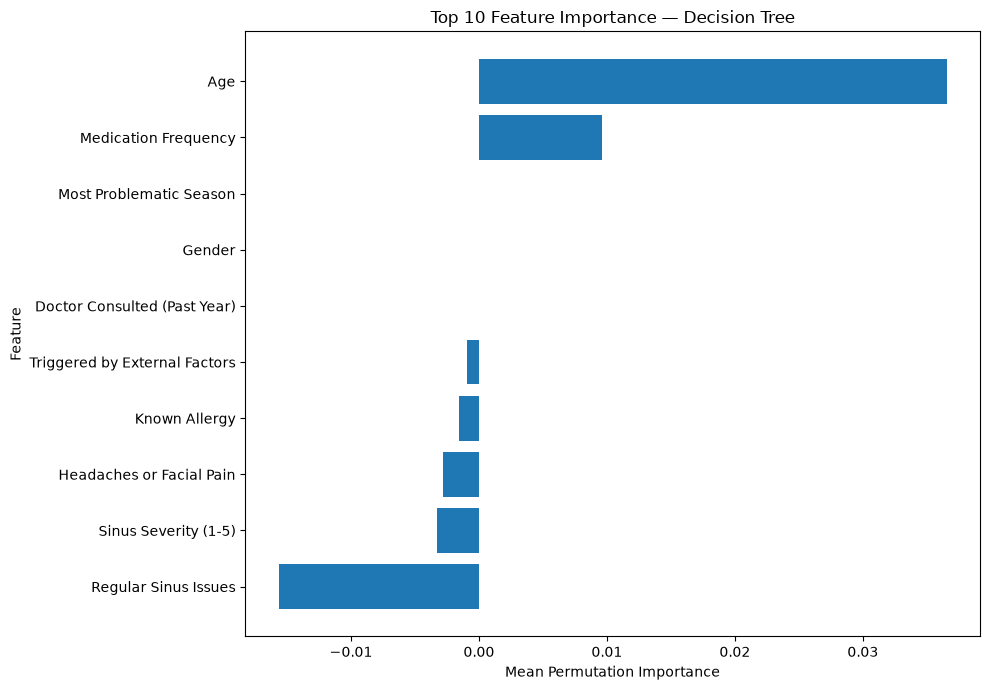


Best model saved as:
best_sinus_condition_model.pkl


CLASSIFICATION REPORT — Decision Tree
              precision    recall  f1-score   support

No Diagnosis       0.48      0.29      0.36       100
   Diagnosis       0.49      0.68      0.57       100

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.46       200
weighted avg       0.48      0.48      0.46       200



STEP 3 COMPLETED SUCCESSFULLY

GENERATED FILES:

1. final_model_results.csv
2. hyperparameter_tuning_results.csv
3. final_model_comparison.png
4. final_confusion_matrices.png
5. final_roc_curves.png
6. feature_importance.csv
7. feature_importance.png
8. best_sinus_condition_model.pkl


PROJECT PROGRESS

Dataset Selection                 ✅
Dataset Understanding             ✅
Univariate EDA                    ✅
Bivariate EDA                     ✅
Missing Value Analysis            ✅
Duplicate Removal                 ✅
Data Preprocessing                ✅
Train/Test Split     

In [ ]:
# ============================================================
# STEP 3 FINALIZATION
# FIXED PERMUTATION IMPORTANCE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report


print("=" * 80)
print("STEP 3 FINALIZATION — FEATURE IMPORTANCE")
print("=" * 80)


# ============================================================
# 1. CHECK FINAL RESULTS
# ============================================================

print("\nFinal model performance:")

display(
    final_results_percentage.sort_values(
        by="F1-Score",
        ascending=False
    )
)


# ============================================================
# 2. SELECT MODEL FOR EXPLAINABILITY
# ============================================================

best_model_name = final_results_df.loc[
    final_results_df["F1-Score"].idxmax(),
    "Model"
]

best_model = tuned_models[best_model_name]

print("\n")
print("=" * 80)
print("MODEL SELECTED FOR EXPLAINABILITY")
print("=" * 80)

print("Selected model:", best_model_name)


# ============================================================
# 3. PERMUTATION IMPORTANCE
# ============================================================

print("\nCalculating permutation importance...")

perm = permutation_importance(
    best_model,
    X_test_final,
    y_test_final,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


# IMPORTANT:
# Because permutation_importance was applied to the complete
# pipeline using the ORIGINAL X_test data, the importance
# values correspond directly to the original 10 features.

original_feature_names = X_test_final.columns.tolist()


print("\nNumber of original features:",
      len(original_feature_names))

print("Number of importance values:",
      len(perm.importances_mean))


# ============================================================
# 4. CREATE FEATURE IMPORTANCE TABLE
# ============================================================

importance_df = pd.DataFrame({

    "Feature": original_feature_names,

    "Importance Mean": perm.importances_mean,

    "Importance Std": perm.importances_std

})


importance_df = importance_df.sort_values(
    by="Importance Mean",
    ascending=False
)


print("\n")
print("=" * 80)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 80)

display(
    importance_df
)


# ============================================================
# 5. TOP 10 FEATURES
# ============================================================

top_features = importance_df.head(10)

print("\n")
print("=" * 80)
print("TOP 10 FEATURES")
print("=" * 80)

display(
    top_features
)


# ============================================================
# 6. FEATURE IMPORTANCE GRAPH
# ============================================================

plot_features = (
    importance_df
    .head(10)
    .sort_values(
        by="Importance Mean"
    )
)


plt.figure(
    figsize=(10, 7)
)

plt.barh(
    plot_features["Feature"],
    plot_features["Importance Mean"]
)

plt.xlabel(
    "Mean Permutation Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"Top 10 Feature Importance — {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. SAVE FEATURE IMPORTANCE
# ============================================================

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)


# ============================================================
# 8. SAVE BEST MODEL
# ============================================================

joblib.dump(
    best_model,
    "best_sinus_condition_model.pkl"
)

print("\nBest model saved as:")
print("best_sinus_condition_model.pkl")


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 80)
print(
    f"CLASSIFICATION REPORT — {best_model_name}"
)
print("=" * 80)

print(
    classification_report(
        y_test_final,
        predictions[best_model_name],
        target_names=[
            "No Diagnosis",
            "Diagnosis"
        ],
        zero_division=0
    )
)


# ============================================================
# 10. CHECK ALL GENERATED RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
GENERATED FILES:

1. final_model_results.csv
2. hyperparameter_tuning_results.csv
3. final_model_comparison.png
4. final_confusion_matrices.png
5. final_roc_curves.png
6. feature_importance.csv
7. feature_importance.png
8. best_sinus_condition_model.pkl
""")


# ============================================================
# 11. PROJECT PROGRESS
# ============================================================

print("""
============================================================
PROJECT PROGRESS
============================================================

Dataset Selection                 ✅
Dataset Understanding             ✅
Univariate EDA                    ✅
Bivariate EDA                     ✅
Missing Value Analysis            ✅
Duplicate Removal                 ✅
Data Preprocessing                ✅
Train/Test Split                  ✅
6 Initial ML Models               ✅
Initial Model Evaluation          ✅
5-Fold Cross-Validation            ✅
Hyperparameter Tuning              ✅
Final Test Evaluation              ✅
Confusion Matrices                 ✅
ROC Curves                         ✅
Feature Importance                 ✅

20-Paper Literature Review         ⏳ NEXT
Research Gap                       ⏳
Literature Comparison              ⏳
Discussion                         ⏳
Final Word Report                  ⏳
GitHub Repository                  ⏳
"""
)

print("=" * 80)


In [ ]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

# Your tuned Decision Tree pipeline
best_dt = tuned_models["Decision Tree"]

# Separate preprocessing and model
preprocessor = best_dt.named_steps["preprocessor"]
model = best_dt.named_steps["model"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()

# Create DataFrame
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Use only 100 test samples for fast SHAP calculation
X_shap_sample = X_test_shap.iloc[:100].copy()

print("SHAP input shape:", X_shap_sample.shape)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap_sample)

print("SHAP calculation completed!")

SHAP version: 0.52.0


NameError: name 'tuned_models' is not defined

In [ ]:
# Show variables currently available
%whos

Variable   Type      Data/Info
------------------------------
np         module    <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd         module    <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
shap       module    <module 'shap' from 'c:\\<...>ages\\shap\\__init__.py'>


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:
print(RandomizedSearchCV)

<class 'sklearn.model_selection._search.RandomizedSearchCV'>


In [ ]:
%whos

Variable                 Type        Data/Info
----------------------------------------------
CatBoostClassifier       type        <class 'catboost.core.CatBoostClassifier'>
ColumnTransformer        ABCMeta     <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DecisionTreeClassifier   ABCMeta     <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LogisticRegression       type        <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type        <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                 ABCMeta     <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta     <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
RandomizedSearchCV       ABCMeta     <class 'sklearn.model_sel<...>arch.RandomizedSearchCV'>
SVC                      ABCMeta     <class 'sklearn.svm._classes.SVC'>
StandardScaler           type        <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold          ABCMe

In [ ]:
# Load dataset
df = pd.read_csv("sinus_survey_data1.csv")

# Remove duplicates
df_clean = df.drop_duplicates().copy()

# Features and target
X = df_clean.drop("Diagnosed with Sinus Condition", axis=1)
y = df_clean["Diagnosed with Sinus Condition"]

# Convert target to binary
y_binary = (y == "Yes").astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Cleaned dataset:", df_clean.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Cleaned dataset: (1000, 11)
X_train: (800, 10)
X_test: (200, 10)
y_train: (800,)
y_test: (200,)


In [ ]:
numeric_features = [
    "Age",
    "Sinus Severity (1-5)"
]

categorical_features = [
    "Gender",
    "Regular Sinus Issues",
    "Most Problematic Season",
    "Triggered by External Factors",
    "Known Allergy",
    "Doctor Consulted (Past Year)",
    "Headaches or Facial Pain",
    "Medication Frequency"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__criterion": ["gini", "entropy", "log_loss"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_search = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=dt_param_grid,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

print("Decision Tree tuning completed.")
print("Best CV F1:", dt_search.best_score_)
print("Best parameters:", dt_search.best_params_)

Decision Tree tuning completed.
Best CV F1: 0.5213757936174465
Best parameters: {'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': 5, 'model__criterion': 'gini'}


In [ ]:
best_dt_pipeline = dt_search.best_estimator_

best_dt_model = best_dt_pipeline.named_steps["model"]
fitted_preprocessor = best_dt_pipeline.named_steps["preprocessor"]

print(best_dt_model)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)


In [ ]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
CatBoostClassifier       type                      <class 'catboost.core.CatBoostClassifier'>
ColumnTransformer        ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
RandomizedSearchCV       ABCMeta                   <class 'sklearn.model_sel<...>arch.RandomizedSearchCV'>
SVC                      ABCMeta                   <cla

In [ ]:
# Transform test data using the fitted preprocessing pipeline
X_test_transformed = fitted_preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (200, 18)


In [ ]:
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 18
['num__Age' 'num__Sinus Severity (1-5)' 'cat__Gender_Female'
 'cat__Gender_Male' 'cat__Regular Sinus Issues_No'
 'cat__Regular Sinus Issues_Yes'
 'cat__Most Problematic Season_Monsoon / Rainy'
 'cat__Most Problematic Season_Winter'
 'cat__Triggered by External Factors_No'
 'cat__Triggered by External Factors_Yes' 'cat__Known Allergy_No'
 'cat__Known Allergy_Yes' 'cat__Doctor Consulted (Past Year)_No'
 'cat__Doctor Consulted (Past Year)_Yes'
 'cat__Headaches or Facial Pain_No' 'cat__Headaches or Facial Pain_Yes'
 'cat__Medication Frequency_Occasionally'
 'cat__Medication Frequency_Regularly']


In [ ]:
if hasattr(X_test_transformed, "toarray"):
    X_test_shap = X_test_transformed.toarray()
else:
    X_test_shap = X_test_transformed

print("SHAP input shape:", X_test_shap.shape)

SHAP input shape: (200, 18)


In [ ]:
explainer = shap.TreeExplainer(best_dt_model)

shap_explanation = explainer(X_test_shap)

print("SHAP values shape:", shap_explanation.values.shape)

SHAP values shape: (200, 18, 2)


In [ ]:
shap_values = shap_explanation.values

if shap_values.ndim == 3:
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values

print("Final SHAP shape:", shap_values_positive.shape)

Final SHAP shape: (200, 18)


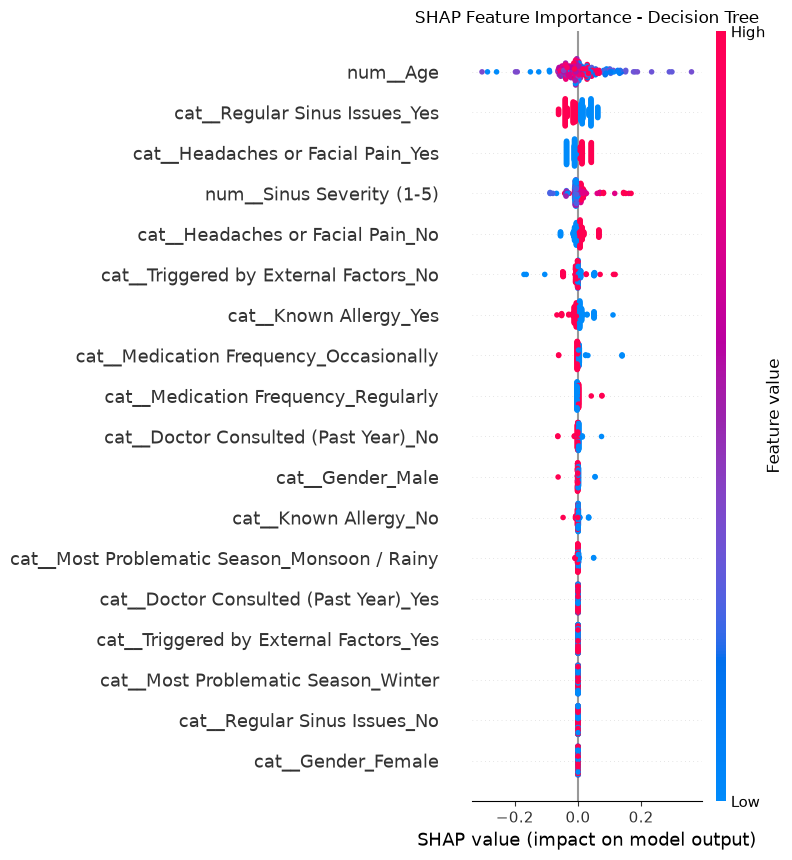

In [ ]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_positive,
    X_test_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Decision Tree")
plt.tight_layout()

plt.savefig(
    "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
shap_importance = np.abs(shap_values_positive).mean(axis=0)

shap_results = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": shap_importance
})

shap_results = shap_results.sort_values(
    "Mean Absolute SHAP",
    ascending=False
).reset_index(drop=True)

shap_results["Mean Absolute SHAP"] = (
    shap_results["Mean Absolute SHAP"].round(6)
)

print(shap_results.to_string(index=False))

                                     Feature  Mean Absolute SHAP
                                    num__Age            0.051637
               cat__Regular Sinus Issues_Yes            0.026117
           cat__Headaches or Facial Pain_Yes            0.019355
                   num__Sinus Severity (1-5)            0.018509
            cat__Headaches or Facial Pain_No            0.013388
       cat__Triggered by External Factors_No            0.012760
                      cat__Known Allergy_Yes            0.011923
      cat__Medication Frequency_Occasionally            0.005377
         cat__Medication Frequency_Regularly            0.003018
        cat__Doctor Consulted (Past Year)_No            0.002690
                            cat__Gender_Male            0.001804
                       cat__Known Allergy_No            0.001765
cat__Most Problematic Season_Monsoon / Rainy            0.001403
                cat__Regular Sinus Issues_No            0.000000
      cat__Triggered by E

In [ ]:
shap_results.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("Saved: shap_feature_importance.csv")

Saved: shap_feature_importance.csv


In [ ]:
df = pd.read_csv("../data/sinus_survey_data1.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1006, 11)


,Age,Gender,Regular Sinus Issues,Most Problematic Season,Triggered by External Factors,Known Allergy,Doctor Consulted (Past Year),Sinus Severity (1-5),Diagnosed with Sinus Condition,Headaches or Facial Pain,Medication Frequency
0,43,Female,No,Monsoon / Rainy,Yes,Yes,No,4,Yes,No,Occasionally
1,55,Female,Yes,Monsoon / Rainy,No,Yes,Yes,3,Yes,Yes,Occasionally
2,48,Male,Yes,Winter,Yes,Yes,No,2,No,Yes,Occasionally
3,65,Male,Yes,Winter,Yes,No,Yes,4,No,Yes,Occasionally
4,34,Female,No,Winter,Yes,No,Yes,1,No,Yes,Regularly
